# A1 — Vision Transformers para inspeção visual de qualidade em fundição

**Disciplina:** Visão Computacional com CNNs e Transformers [26E3_3] — INFNET · **Aluno:** Lucas de Oliveira Ferreira

**Problema:** classificar rotores de bombas submersíveis fundidos (vista superior) em **defeituoso** (`def_front`) ou **OK** (`ok_front`). É uma tarefa real de controle de qualidade industrial: a inspeção hoje é manual, lenta e sujeita a erro, e deixar passar uma peça defeituosa (falso negativo) pode levar à rejeição de um lote inteiro.

**Dataset:** [Casting Product Image Data for Quality Inspection](https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product) (Ravirajsinh Dabhi, CC BY-NC-ND 4.0) — usamos o subconjunto **`casting_512x512` (1.300 imagens sem augmentation: 781 defeituosas, 519 OK)**.

| Requisito | Valor estimado (Colab T4) |
|---|---|
| GPU | T4 (16 GB) — pico ~6 GB de VRAM no fine-tuning do ViT-B/16 (batch 32, AMP) |
| RAM | ~4 GB |
| Disco | ~0,5 GB (zip de 105 MB + pesos do ViT-B/16, 330 MB) |
| Tempo total | ~15–25 min no T4 (E1 ~4 min, E2 < 1 min, E3 ~4 min, E4 ~4 min, atenção ~1 min) — **medido: 11,3 min** numa RTX 3050 6 GB, sem contar o download |

**Como rodar:** `Ambiente de execução → Alterar tipo → T4 GPU` → `Executar tudo`. Sem Drive e sem `kaggle.json`.

**Uso de IA:** código e texto elaborados com apoio do Claude (Anthropic), revisados e executados pelo aluno; números e figuras são outputs reais deste notebook.

**Base nas aulas:** Aula 02 (self-attention, multi-head, bloco Pre-LN), Aula 03 (fine-tuning com LR baixo e warmup; feature extraction), Aula 04 (patch embedding com Conv2d, [CLS], position embeddings, fome de dados do ViT, CutMix, attention rollout), Aula 05 (atenção do [CLS] por cabeça), Aula 08 (hook/leitura dos pesos de atenção, overlay, atalhos espúrios, métricas por classe).

## 0. Setup

In [1]:
import os, sys, time, json, math, random, zipfile, shutil, urllib.request, copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms as T
from torchvision.transforms import v2
from torchvision.models import vit_b_16, ViT_B_16_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve, precision_recall_curve)

IN_COLAB = "google.colab" in sys.modules
DATA_ROOT = Path(os.environ.get("DATA_ROOT", "/content/data" if IN_COLAB else "data")).resolve()
FIG_DIR = Path(os.environ.get("FIG_DIR", "figs/A1")).resolve(); FIG_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
VRAM_GB = torch.cuda.get_device_properties(0).total_memory / 1e9 if DEVICE == "cuda" else 0

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

def savefig(name):
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

CONFIG = dict(
    seed=42, img_size=224, batch_size=32, num_workers=2 if os.name != "nt" else 0,
    # Em GPUs com < 10 GB (ex.: notebook local) o batch efetivo de 32 é mantido por acumulação de gradiente.
    micro_batch=32 if VRAM_GB >= 10 or DEVICE == "cpu" else 16,
    scratch=dict(dim=192, depth=6, heads=3, epochs=40, lr=5e-4, wd=0.05, warmup=4),
    probe=dict(epochs=40, lr=1e-3),
    finetune=dict(epochs=10, lr_backbone=3e-5, lr_head=1e-3, wd=0.05, warmup=1),
    cutmix_alpha=1.0,
)
seed_everything(CONFIG["seed"])
print("torch", torch.__version__, "| torchvision", torchvision.__version__, "| device", DEVICE,
      f"| VRAM {VRAM_GB:.1f} GB | micro-batch {CONFIG['micro_batch']}")

torch 2.14.1+cu126 | torchvision 0.29.1+cu126 | device cuda | VRAM 6.4 GB | micro-batch 16


## 1. Dados

**Por que o subconjunto 512×512 e não as 7.348 imagens 300×300:** o autor do dataset informa que as imagens 300×300 **já vêm com augmentation aplicada** (várias versões rotacionadas/espelhadas da mesma peça). Se usássemos esse conjunto e o dividíssemos, versões da mesma peça poderiam cair no treino e no teste — vazamento que infla as métricas. As 1.300 imagens 512×512 são as fotos originais, uma por peça. Fazemos o nosso próprio split e a nossa própria augmentation, só no treino.

In [2]:
class Archive:
    def __init__(self, path):
        self.path = Path(path); self.zf = zipfile.ZipFile(self.path) if self.path.is_file() else None
    def names(self):
        if self.zf: return [n for n in self.zf.namelist() if not n.endswith("/")]
        return [p.relative_to(self.path).as_posix() for p in self.path.rglob("*") if p.is_file()]
    def extract(self, name, dest_root):
        out = Path(dest_root) / name; out.parent.mkdir(parents=True, exist_ok=True)
        if self.zf:
            with self.zf.open(name) as s, open(out, "wb") as d: shutil.copyfileobj(s, d)
        else: shutil.copy(self.path / name, out)

def kaggle_archive(ref, name):
    zpath = DATA_ROOT / "_zips" / f"{name}.zip"
    if zpath.exists(): return Archive(zpath)
    zpath.parent.mkdir(parents=True, exist_ok=True)
    try:
        with urllib.request.urlopen(f"https://www.kaggle.com/api/v1/datasets/download/{ref}", timeout=600) as r, \
             open(f"{zpath}.part", "wb") as f:
            shutil.copyfileobj(r, f, 1 << 20)
        os.replace(f"{zpath}.part", zpath); return Archive(zpath)
    except Exception as e:
        print("Download anônimo falhou:", e, "→ kagglehub"); import kagglehub
        return Archive(kagglehub.dataset_download(ref))

CAST_DIR = DATA_ROOT / "casting"
SRC = CAST_DIR / "casting_512x512" / "casting_512x512"
if not SRC.exists():
    arc = kaggle_archive("ravirajsinh45/real-life-industrial-dataset-of-casting-product", "casting")
    for n in arc.names():
        if n.startswith("casting_512x512/"): arc.extract(n, CAST_DIR)
CLASSES = ["ok_front", "def_front"]          # índice 1 = defeituoso = classe positiva
df = pd.DataFrame([dict(path=str(p), label=c) for c in CLASSES for p in sorted((SRC / c).glob("*.jpeg"))])
df["y"] = df.label.map({c: i for i, c in enumerate(CLASSES)})
print(df.label.value_counts())

label
def_front    781
ok_front     519
Name: count, dtype: int64


### Exploração: exemplos e um possível atalho (fundo)

As fotos foram tiradas sobre **dois tipos de fundo** (papel branco e superfície cinza). Se a proporção de fundos for diferente entre as classes, um modelo pode aprender "fundo cinza ⇒ OK" em vez de olhar a peça — um *shortcut* clássico (Aula 08). Medimos o brilho médio dos cantos da imagem (onde só há fundo) por classe.

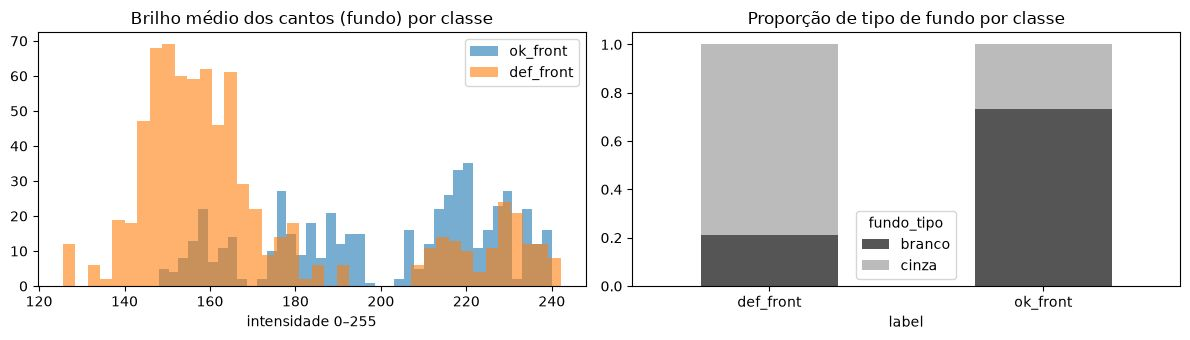

fundo_tipo,branco,cinza,All
label,,,
def_front,164,617,781
ok_front,380,139,519
All,544,756,1300


In [3]:
def corner_brightness(path, k=40):
    a = np.asarray(Image.open(path).convert("L"), dtype=np.float32)
    return float(np.mean([a[:k, :k].mean(), a[:k, -k:].mean(), a[-k:, :k].mean(), a[-k:, -k:].mean()]))
df["fundo"] = df.path.map(corner_brightness)
df["fundo_tipo"] = np.where(df.fundo > 180, "branco", "cinza")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
for c in CLASSES: ax[0].hist(df[df.label == c].fundo, bins=40, alpha=.6, label=c)
ax[0].set_title("Brilho médio dos cantos (fundo) por classe"); ax[0].set_xlabel("intensidade 0–255"); ax[0].legend()
pd.crosstab(df.label, df.fundo_tipo, normalize="index").plot.bar(ax=ax[1], stacked=True, rot=0, color=["#bbb", "#555"][::-1])
ax[1].set_title("Proporção de tipo de fundo por classe")
plt.tight_layout(); savefig("01_fundo_por_classe"); plt.show()
pd.crosstab(df.label, df.fundo_tipo, margins=True)

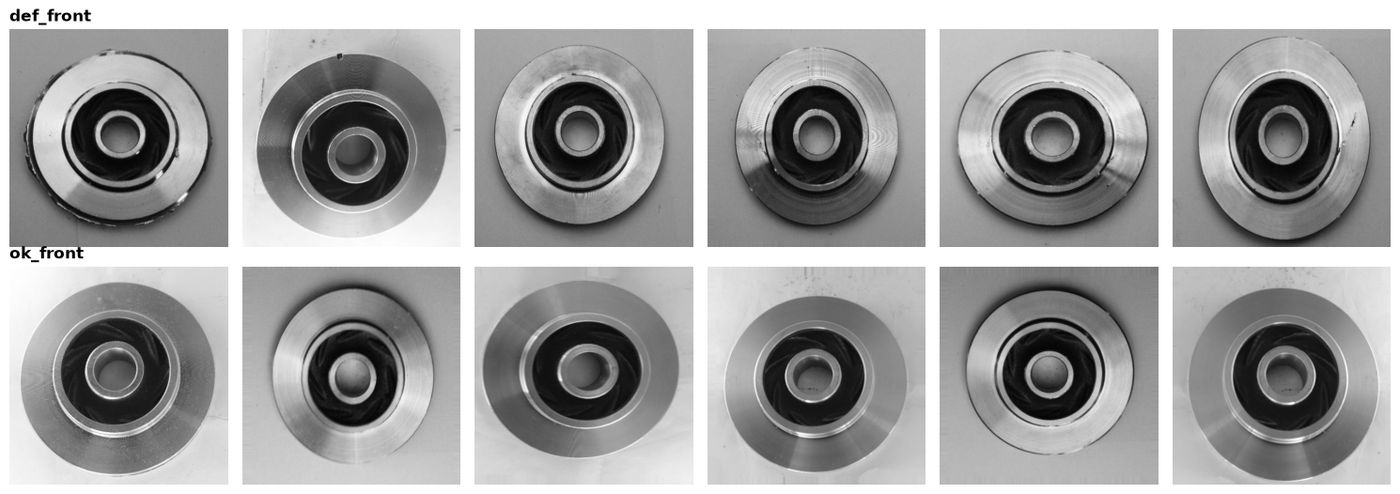

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(15, 5.3))
for i, c in enumerate(CLASSES[::-1]):
    for j, p in enumerate(df[df.label == c].sample(6, random_state=3).path):
        axes[i, j].imshow(Image.open(p).convert("RGB")); axes[i, j].axis("off")
    axes[i, 0].set_title(c, loc="left", fontweight="bold")
plt.tight_layout(); savefig("02_exemplos"); plt.show()

### Split estratificado 70/15/15

Estratificado por classe **e** por tipo de fundo, para que validação e teste tenham a mesma mistura de fundos do treino. O teste é usado uma única vez, ao final.

In [5]:
strat = df.label + "_" + df.fundo_tipo
i_tr, i_tmp = train_test_split(df.index, test_size=0.30, stratify=strat, random_state=CONFIG["seed"])
i_va, i_te = train_test_split(i_tmp, test_size=0.50, stratify=strat[i_tmp], random_state=CONFIG["seed"])
splits = {"train": df.loc[i_tr], "val": df.loc[i_va], "test": df.loc[i_te]}
pd.DataFrame({k: v.label.value_counts() for k, v in splits.items()})

,train,val,test
label,,,
def_front,547,117,117
ok_front,363,78,78


### Pré-processamento e augmentation

- **Normalização:** média/desvio do ImageNet, a mesma do pré-treino do ViT-B/16 (Aula 01/08). As imagens são em tons de cinza; replicamos o canal em 3 (RGB) para usar o backbone sem alterar a primeira camada.
- **Augmentation (só no treino):** a peça é **circular e fotografada de cima** — o defeito pode estar em qualquer posição do anel e a classe não muda com rotação ou espelhamento. Usamos o **grupo diedral D4** (rotações de 0/90/180/270° + espelhamentos): são transformações **sem perda**, que não criam cantos pretos nem interpolação (uma rotação arbitrária preencheria os cantos com uma cor que não existe nas imagens reais). Somamos *jitter* leve de brilho/contraste, pois a iluminação varia entre fotos. Não usamos jitter de cor (imagens em cinza) nem recortes agressivos (o defeito costuma estar na borda da peça e um recorte pode removê-lo, trocando o rótulo — Aula 08).

In [6]:
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

class RandomD4:
    def __call__(self, img):
        img = img.rotate(90 * random.randint(0, 3))
        return img.transpose(Image.FLIP_LEFT_RIGHT) if random.random() < 0.5 else img

tf_train = T.Compose([T.Resize(CONFIG["img_size"]), RandomD4(), T.ColorJitter(brightness=0.2, contrast=0.2),
                      T.ToTensor(), T.Normalize(MEAN, STD)])
tf_eval = T.Compose([T.Resize(CONFIG["img_size"]), T.ToTensor(), T.Normalize(MEAN, STD)])

_IMG_CACHE = {}
def load_img(p):
    """Decodifica o JPEG 512×512 e reduz para 224 uma única vez (cache em memória, ~200 MB): o gargalo do treino deixa de ser a CPU."""
    if p not in _IMG_CACHE:
        _IMG_CACHE[p] = Image.open(p).convert("RGB").resize((CONFIG["img_size"], CONFIG["img_size"]), Image.BILINEAR)
    return _IMG_CACHE[p]

class CastDS(torch.utils.data.Dataset):
    def __init__(self, frame, tf): self.p, self.y, self.tf = frame.path.tolist(), frame.y.tolist(), tf
    def __len__(self): return len(self.p)
    def __getitem__(self, i): return self.tf(load_img(self.p[i])), self.y[i]

def loader(split, tf, shuffle=False, bs=None):
    g = torch.Generator().manual_seed(CONFIG["seed"])
    return torch.utils.data.DataLoader(CastDS(splits[split], tf), batch_size=bs or CONFIG["micro_batch"], shuffle=shuffle,
                                       num_workers=CONFIG["num_workers"], generator=g, drop_last=False,
                                       worker_init_fn=lambda w: random.seed(CONFIG["seed"] + w))

## 2. Do mecanismo de atenção ao Vision Transformer

### 2.1 Scaled dot-product attention e multi-head attention do zero (módulos testáveis)

Primeiro escrevemos o mecanismo na forma mais didática (Aula 02), como módulos PyTorch independentes:

- **`ScaledDotProductAttention`**: `Attention(Q, K, V) = softmax(QKᵀ / √d_k) · V`. A divisão por √d_k mantém a variância dos *scores* em ~1; sem ela, com d_k = 64 o softmax vira quase um degrau e o gradiente some (Aula 02). Aceita uma máscara opcional (posições com 0 recebem −∞ antes do softmax).
- **`AttentionHead`**: uma cabeça com **projeções próprias e independentes** `W_Q, W_K, W_V ∈ ℝ^(D×d_k)`.
- **`MultiHeadAttention`**: *h* cabeças independentes (`nn.ModuleList`), **concatenação** das saídas (`[B, T, h·d_k]`) e projeção de saída `W_O`. Com D = 768 e h = 12, d_k = 64.

Os testes abaixo verificam formas, normalização das linhas, equivalência com as implementações oficiais do PyTorch e propriedades do mecanismo.

In [7]:
class ScaledDotProductAttention(nn.Module):
    def forward(self, q, k, v, mask=None):                       # q,k: [..., T, d_k]  v: [..., T, d_v]
        scores = q @ k.transpose(-2, -1) / math.sqrt(q.size(-1))  # [..., T, T]
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn = scores.softmax(dim=-1)
        return attn @ v, attn

class AttentionHead(nn.Module):
    """Uma cabeça de atenção com projeções Q, K, V próprias."""
    def __init__(self, dim, d_k):
        super().__init__()
        self.W_q, self.W_k, self.W_v = nn.Linear(dim, d_k), nn.Linear(dim, d_k), nn.Linear(dim, d_k)
        self.sdpa = ScaledDotProductAttention()
    def forward(self, x, mask=None):
        return self.sdpa(self.W_q(x), self.W_k(x), self.W_v(x), mask)

class MultiHeadAttention(nn.Module):
    """h cabeças independentes → concatenação → W_O."""
    def __init__(self, dim, heads):
        super().__init__()
        assert dim % heads == 0
        self.heads = nn.ModuleList([AttentionHead(dim, dim // heads) for _ in range(heads)])
        self.W_o = nn.Linear(dim, dim)
    def forward(self, x, mask=None):
        outs, attns = zip(*[h(x, mask) for h in self.heads])
        return self.W_o(torch.cat(outs, dim=-1)), torch.stack(attns, dim=1)      # [B, T, D], [B, h, T, T]

# ---------------- testes ----------------
torch.manual_seed(0)
B, T_, D_, H_ = 2, 10, 64, 4
x = torch.randn(B, T_, D_)
mha = MultiHeadAttention(D_, H_).eval()
y, A = mha(x)
assert y.shape == (B, T_, D_) and A.shape == (B, H_, T_, T_)
assert torch.allclose(A.sum(-1), torch.ones(B, H_, T_), atol=1e-6)                          # cada linha do softmax soma 1
print("1) formas e normalização das linhas: OK")

q, k, v = torch.randn(3, B, H_, T_, 16).unbind(0)
assert torch.allclose(ScaledDotProductAttention()(q, k, v)[0], F.scaled_dot_product_attention(q, k, v), atol=1e-5)
print("2) ScaledDotProductAttention == torch.nn.functional.scaled_dot_product_attention: OK")

ref = nn.MultiheadAttention(D_, H_, batch_first=True).eval()                                  # implementação oficial
dk = D_ // H_
with torch.no_grad():
    for i, h in enumerate(mha.heads):                                                         # copia as projeções de cada cabeça
        for j, W in enumerate([h.W_q, h.W_k, h.W_v]):
            ref.in_proj_weight[j * D_ + i * dk: j * D_ + (i + 1) * dk] = W.weight
            ref.in_proj_bias[j * D_ + i * dk: j * D_ + (i + 1) * dk] = W.bias
    ref.out_proj.weight.copy_(mha.W_o.weight); ref.out_proj.bias.copy_(mha.W_o.bias)
    y_ref, A_ref = ref(x, x, x, need_weights=True, average_attn_weights=False)
assert torch.allclose(y, y_ref, atol=1e-5) and torch.allclose(A, A_ref, atol=1e-6)
print("3) MultiHeadAttention (cabeças independentes) == torch.nn.MultiheadAttention: OK")

mask = torch.ones(T_, T_); mask[:, -3:] = 0                                                   # bloqueia as 3 últimas chaves
_, A_m = mha(x, mask)
assert torch.all(A_m[..., -3:] == 0)
print("4) máscara: posições mascaradas recebem peso 0: OK")

perm = torch.randperm(T_)
y_perm, _ = mha(x[:, perm])
assert torch.allclose(y_perm, y[:, perm], atol=1e-5)
print("5) equivariância a permutação: MHA(Px) = P·MHA(x) — sem positional encoding, a atenção não sabe a ordem dos tokens: OK")

1) formas e normalização das linhas: OK
2) ScaledDotProductAttention == torch.nn.functional.scaled_dot_product_attention: OK
3) MultiHeadAttention (cabeças independentes) == torch.nn.MultiheadAttention: OK
4) máscara: posições mascaradas recebem peso 0: OK
5) equivariância a permutação: MHA(Px) = P·MHA(x) — sem positional encoding, a atenção não sabe a ordem dos tokens: OK


O **teste 5** é a razão de existir do *positional encoding*: a atenção trata a entrada como um **conjunto**, não como uma sequência. Se embaralharmos os tokens, a saída sai embaralhada do mesmo jeito, mas com os mesmos valores, então nenhuma informação de posição é usada. Numa imagem, isso significa que o modelo não distinguiria "defeito na borda" de "defeito no centro", nem saberia quais patches são vizinhos. Voltamos a isso na seção 2.3, com o ViT pré-treinado.

### 2.2 Os blocos do ViT

Para treinar, o ViT usa uma implementação **fundida** e matematicamente idêntica da mesma multi-head attention (**`MultiHeadSelfAttention`**). As projeções de todas as cabeças ficam numa única `Linear(D, 3D)` (as matrizes W_Q, W_K, W_V das *h* cabeças empilhadas), e a separação em cabeças é feita por `reshape`. São 3 multiplicações grandes em vez de 3·h pequenas, que é o formato dos pesos pré-treinados do TorchVision. O **teste 6**, logo abaixo, prova a equivalência numérica com a versão de cabeças independentes. A versão fundida devolve a matriz de atenção `[B, heads, T, T]` para a visualização. No treino, quando os pesos não são necessários, ela usa `F.scaled_dot_product_attention` (validado no teste 2).

1. **`PatchEmbedding`**: `Conv2d(3, D, kernel=16, stride=16)`. Fatiar em patches 16×16 e projetar linearmente é exatamente uma convolução com *stride* igual ao *kernel* (Aula 04). 224×224 → 14×14 = 196 patches.
2. **`TransformerEncoderBlock` (Pre-LN)**: `z' = MSA(LN(z)) + z` e `z = MLP(LN(z')) + z'`, com *feedforward* de duas camadas (`Linear(D, 4D)` → GELU → `Linear(4D, D)`), dois `LayerNorm` e duas conexões residuais (Aula 02/04).
3. **`ViT`**: token [CLS] aprendido + *position embeddings* 1D aprendidos (197 × D), *N* blocos, `LayerNorm` final e cabeça `Linear(D, C)` sobre o [CLS] (Aula 04/05).

In [8]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, heads, attn_drop=0.0):
        super().__init__()
        assert dim % heads == 0
        self.heads, self.d_k, self.attn_drop = heads, dim // heads, attn_drop
        self.qkv = nn.Linear(dim, 3 * dim)      # [W_Q; W_K; W_V]
        self.proj = nn.Linear(dim, dim)         # W_O

    def forward(self, x, return_attn=False):
        B, T_, D = x.shape
        q, k, v = self.qkv(x).reshape(B, T_, 3, self.heads, self.d_k).permute(2, 0, 3, 1, 4)   # 3 × [B, h, T, d_k]
        if return_attn:
            scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)                           # [B, h, T, T]
            attn = scores.softmax(dim=-1)
            out = attn @ v
        else:
            attn = None
            out = F.scaled_dot_product_attention(q, k, v, dropout_p=self.attn_drop if self.training else 0.0)
        out = out.transpose(1, 2).reshape(B, T_, D)                                             # concatena as cabeças
        return self.proj(out), attn

class PatchEmbedding(nn.Module):
    def __init__(self, patch=16, in_ch=3, dim=768):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, dim, kernel_size=patch, stride=patch)
    def forward(self, x):                        # [B, 3, 224, 224] → [B, 196, D]
        return self.proj(x).flatten(2).transpose(1, 2)

class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4, drop=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(dim, eps=1e-6)
        self.attn = MultiHeadSelfAttention(dim, heads)
        self.ln2 = nn.LayerNorm(dim, eps=1e-6)
        self.mlp = nn.Sequential(nn.Linear(dim, mlp_ratio * dim), nn.GELU(), nn.Dropout(drop),
                                 nn.Linear(mlp_ratio * dim, dim), nn.Dropout(drop))
    def forward(self, x, return_attn=False):
        h, attn = self.attn(self.ln1(x), return_attn)
        x = x + h
        x = x + self.mlp(self.ln2(x))
        return x, attn

class ViT(nn.Module):
    def __init__(self, img=224, patch=16, dim=768, depth=12, heads=12, num_classes=1000, drop=0.0):
        super().__init__()
        self.patch_embed = PatchEmbedding(patch, 3, dim)
        n = (img // patch) ** 2
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n + 1, dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02); nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.drop = nn.Dropout(drop)
        self.blocks = nn.ModuleList([TransformerEncoderBlock(dim, heads, drop=drop) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim, eps=1e-6)
        self.head = nn.Linear(dim, num_classes)
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def features(self, x, return_attn=False):
        x = self.patch_embed(x)
        x = torch.cat([self.cls_token.expand(x.shape[0], -1, -1), x], dim=1) + self.pos_embed   # [B, 197, D]
        x = self.drop(x)
        attns = []
        for blk in self.blocks:
            x, a = blk(x, return_attn)
            attns.append(a)
        return self.norm(x)[:, 0], attns          # representação do [CLS]

    def forward(self, x, return_attn=False):
        z, attns = self.features(x, return_attn)
        logits = self.head(z)
        return (logits, attns) if return_attn else logits

n_params = lambda m, trainable=False: sum(p.numel() for p in m.parameters() if p.requires_grad or not trainable)
print("ViT-B/16 próprio:", f"{n_params(ViT()) / 1e6:.1f} M parâmetros")

fused = MultiHeadSelfAttention(D_, H_).eval()                    # teste 6: versão fundida == cabeças independentes
with torch.no_grad():
    for i, h in enumerate(mha.heads):
        for j, W in enumerate([h.W_q, h.W_k, h.W_v]):
            fused.qkv.weight[j * D_ + i * dk: j * D_ + (i + 1) * dk] = W.weight
            fused.qkv.bias[j * D_ + i * dk: j * D_ + (i + 1) * dk] = W.bias
    fused.proj.weight.copy_(mha.W_o.weight); fused.proj.bias.copy_(mha.W_o.bias)
    y_f, A_f = fused(x, return_attn=True); y_f2, _ = fused(x)
    y, A = mha(x)
assert torch.allclose(y_f, y, atol=1e-5) and torch.allclose(A_f, A, atol=1e-6) and torch.allclose(y_f2, y, atol=1e-5)
print("6) MultiHeadSelfAttention fundida (usada no ViT) == MultiHeadAttention de cabeças independentes: OK")
blk = TransformerEncoderBlock(64, 4)
print("TransformerEncoderBlock:", tuple(blk(torch.randn(2, 197, 64))[0].shape), "| ViT completo (imagem → logits):",
      tuple(ViT(dim=64, depth=2, heads=4, num_classes=2)(torch.randn(1, 3, 224, 224)).shape))

ViT-B/16 próprio: 86.6 M parâmetros
6) MultiHeadSelfAttention fundida (usada no ViT) == MultiHeadAttention de cabeças independentes: OK
TransformerEncoderBlock: (2, 197, 64) | ViT completo (imagem → logits): (1, 2)


### Carregando os pesos pré-treinados do ViT-B/16 no ViT próprio

O pré-treino do ViT-B/16 (ImageNet) é carregado **dentro da nossa implementação**, mapeando o `state_dict` do TorchVision para os nossos módulos (`in_proj` → `qkv`, `out_proj` → `proj`, `mlp.0/3`, etc.). Em seguida comparamos as saídas com o `torchvision.models.vit_b_16` original: se a diferença for desprezível, a arquitetura que escrevemos **é** o ViT-B/16, e temos acesso nativo aos pesos de atenção sem *hooks*.

In [9]:
WEIGHTS = ViT_B_16_Weights.IMAGENET1K_V1
tv_vit = vit_b_16(weights=WEIGHTS, progress=False).eval()

def load_torchvision_vit(model, tv):
    s = tv.state_dict(); m = {}
    m["patch_embed.proj.weight"], m["patch_embed.proj.bias"] = s["conv_proj.weight"], s["conv_proj.bias"]
    m["cls_token"], m["pos_embed"] = s["class_token"], s["encoder.pos_embedding"]
    for i in range(len(model.blocks)):
        p = f"encoder.layers.encoder_layer_{i}."
        for a, b in [("ln1", "ln_1"), ("ln2", "ln_2")]:
            m[f"blocks.{i}.{a}.weight"], m[f"blocks.{i}.{a}.bias"] = s[p + b + ".weight"], s[p + b + ".bias"]
        m[f"blocks.{i}.attn.qkv.weight"], m[f"blocks.{i}.attn.qkv.bias"] = s[p + "self_attention.in_proj_weight"], s[p + "self_attention.in_proj_bias"]
        m[f"blocks.{i}.attn.proj.weight"], m[f"blocks.{i}.attn.proj.bias"] = s[p + "self_attention.out_proj.weight"], s[p + "self_attention.out_proj.bias"]
        for j in (0, 3):
            m[f"blocks.{i}.mlp.{j}.weight"], m[f"blocks.{i}.mlp.{j}.bias"] = s[p + f"mlp.{j}.weight"], s[p + f"mlp.{j}.bias"]
    m["norm.weight"], m["norm.bias"] = s["encoder.ln.weight"], s["encoder.ln.bias"]
    m["head.weight"], m["head.bias"] = s["heads.head.weight"], s["heads.head.bias"]
    model.load_state_dict(m, strict=True)
    return model

pre_vit = load_torchvision_vit(ViT(), tv_vit).eval()
x = torch.stack([tf_eval(Image.open(p).convert("RGB")) for p in df.path.sample(4, random_state=0)])
with torch.no_grad():
    a, b = pre_vit(x), tv_vit(x)
    _, attns_check = pre_vit(x, return_attn=True)
print(f"max |logits_nosso − logits_torchvision| = {(a - b).abs().max().item():.2e}")
print("pesos de atenção por camada:", tuple(attns_check[0].shape), "| linhas somam 1:", torch.allclose(attns_check[0].sum(-1), torch.ones(1)))
assert (a - b).abs().max() < 1e-3
del tv_vit

max |logits_nosso − logits_torchvision| = 3.81e-06
pesos de atenção por camada: (4, 12, 197, 197) | linhas somam 1: True


### 2.3 Positional encoding: por que o ViT precisa dele

O ViT **soma** a cada token um vetor de posição aprendido, `z₀ = [x_cls; x_p¹E; …; x_p¹⁹⁶E] + E_pos`, com `E_pos ∈ ℝ^(197×768)` (Aula 04). A soma, em vez da concatenação, mantém a dimensão D (Aula 02).

**Por que é indispensável.** Pelo teste 5 da seção 2.1, a self-attention é **equivariante a permutações**: `MHA(Px) = P·MHA(x)`. O token [CLS] agrega os demais com pesos que dependem só do **conteúdo** (produtos Q·K). Assim, se os patches forem embaralhados, o [CLS] vê exatamente o mesmo **conjunto** e produz exatamente a mesma saída. Sem PE, uma imagem e a sua versão "quebra-cabeça embaralhado" seriam indistinguíveis. O modelo perderia a noção de vizinhança (bordas e contornos que atravessam patches) e de localização (um defeito na borda e um no cubo pareceriam iguais).

**Teste no ViT-B/16 real:** embaralhamos a ordem dos 196 patches **antes** de somar a posição e comparamos a representação final do [CLS] (1) **sem** E_pos e (2) **com** E_pos.

In [10]:
@torch.no_grad()
def cls_feature(model, x, perm=None, use_pe=True):
    t = model.patch_embed(x)
    if perm is not None:
        t = t[:, perm]                                            # embaralha os patches (quebra-cabeça)
    t = torch.cat([model.cls_token.expand(len(t), -1, -1), t], dim=1)
    if use_pe:
        t = t + model.pos_embed
    for blk in model.blocks:
        t, _ = blk(t)
    return model.norm(t)[:, 0]

xb = torch.stack([tf_eval(load_img(p_)) for p_ in df.path.sample(8, random_state=1)])
perm = torch.randperm(196, generator=torch.Generator().manual_seed(0))
rows = []
for use_pe in [False, True]:
    f0, f1 = cls_feature(pre_vit, xb, None, use_pe), cls_feature(pre_vit, xb, perm, use_pe)
    rows.append(dict(cenário="com positional encoding" if use_pe else "sem positional encoding",
                     max_diferença_absoluta=(f0 - f1).abs().max().item(),
                     cosseno_médio_original_vs_embaralhada=F.cosine_similarity(f0, f1).mean().item()))
pe_tab = pd.DataFrame(rows); pe_tab

,cenário,max_diferença_absoluta,cosseno_médio_original_vs_embaralhada
0,sem positional encoding,0.000003,1.000000
1,com positional encoding,3.509675,0.152189


Sem E_pos, a diferença entre a imagem original e a embaralhada fica no nível do arredondamento numérico: **o modelo não tem como saber a posição de nada**. Com E_pos, a representação muda, porque o modelo "percebe" que a imagem foi desmontada.

**O que os embeddings de posição aprenderam.** Os 196 vetores de posição foram aprendidos como uma lista 1D, sem nenhuma informação de geometria. Mesmo assim, a similaridade de cosseno entre eles revela a **estrutura 2D da imagem**: cada posição é mais parecida com as vizinhas na mesma linha e na mesma coluna. Esse é o mesmo resultado de Dosovitskiy et al. (2021), e o motivo pelo qual embeddings 2D explícitos não trouxeram ganho (Aula 04).

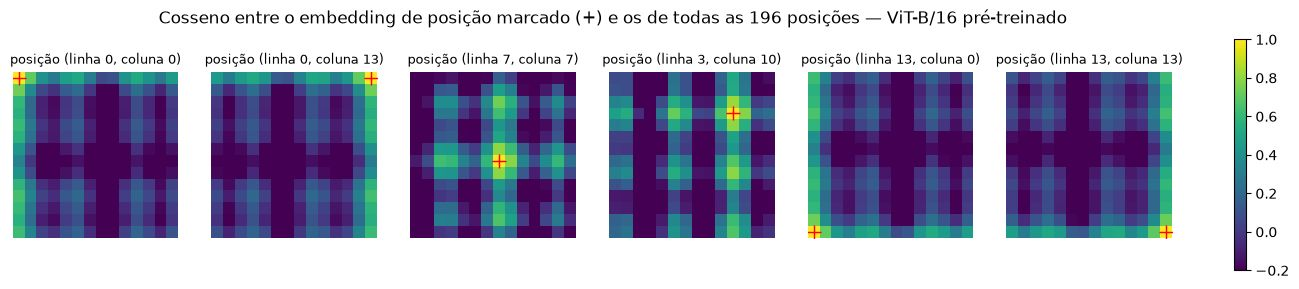

In [11]:
pe = F.normalize(pre_vit.pos_embed[0, 1:].detach(), dim=-1)          # [196, 768]
sim = (pe @ pe.T).reshape(196, 14, 14)
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for a, (r, c_) in zip(axes, [(0, 0), (0, 13), (7, 7), (3, 10), (13, 0), (13, 13)]):
    im = a.imshow(sim[r * 14 + c_].numpy(), cmap="viridis", vmin=-0.2, vmax=1); a.plot(c_, r, "r+", ms=10)
    a.set_title(f"posição (linha {r}, coluna {c_})", fontsize=9); a.axis("off")
fig.colorbar(im, ax=axes, fraction=0.015); fig.suptitle("Cosseno entre o embedding de posição marcado (+) e os de todas as 196 posições — ViT-B/16 pré-treinado")
savefig("02b_pos_embed_similaridade"); plt.show()

## 3. Treino e avaliação — utilitários

- Otimizador **AdamW** com *weight decay* 0,05; *warmup* linear seguido de decaimento *cosine* (receita de fine-tuning de Transformers, Aula 03).
- Precisão mista (AMP) para caber e acelerar no T4.
- Batch efetivo de 32 (com acumulação de gradiente quando a GPU tem pouca VRAM).
- **Seleção de modelo pela validação:** guardamos o checkpoint com maior *balanced accuracy* de validação (desempate pela menor loss). Balanced accuracy, e não accuracy, porque as classes são 60/40 e o custo dos erros é assimétrico (Aula 08).

In [12]:
def cosine_warmup(opt, warmup_steps, total_steps):
    def f(step):
        if step < warmup_steps: return (step + 1) / warmup_steps
        return 0.5 * (1 + math.cos(math.pi * (step - warmup_steps) / max(1, total_steps - warmup_steps)))
    return torch.optim.lr_scheduler.LambdaLR(opt, f)

@torch.no_grad()
def evaluate(model, dl):
    model.eval(); P, Y, L = [], [], 0.0
    for x, y in dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.autocast(device_type="cuda", enabled=DEVICE == "cuda"):
            logits = model(x)
        L += F.cross_entropy(logits.float(), y, reduction="sum").item()
        P.append(torch.softmax(logits.float(), 1)[:, 1].cpu()); Y.append(y.cpu())
    p, y = torch.cat(P).numpy(), torch.cat(Y).numpy()
    pred = (p >= 0.5).astype(int)
    return dict(loss=L / len(y), acc=accuracy_score(y, pred), bacc=balanced_accuracy_score(y, pred),
                recall_def=(pred[y == 1] == 1).mean(), auc=roc_auc_score(y, p)), p, y

def train(model, param_groups, epochs, warmup_epochs, wd, name, cutmix=False):
    seed_everything(CONFIG["seed"])
    model.to(DEVICE)
    dl_tr, dl_va = loader("train", tf_train, shuffle=True), loader("val", tf_eval)
    accum = CONFIG["batch_size"] // CONFIG["micro_batch"]
    steps_per_epoch = math.ceil(len(dl_tr) / accum)
    opt = torch.optim.AdamW(param_groups, weight_decay=wd)
    sched = cosine_warmup(opt, warmup_epochs * steps_per_epoch, epochs * steps_per_epoch)
    scaler = torch.amp.GradScaler(enabled=DEVICE == "cuda")
    mixer = v2.CutMix(num_classes=2, alpha=CONFIG["cutmix_alpha"]) if cutmix else None
    hist, best, t0 = [], None, time.time()
    for ep in range(1, epochs + 1):
        model.train(); tl, tc, n = 0.0, 0, 0
        for it, (x, y) in enumerate(dl_tr):
            x, y = x.to(DEVICE), y.to(DEVICE)
            target = y
            if mixer is not None:
                x, target = mixer(x, y)                    # alvo suave proporcional à área (Aula 04)
            with torch.autocast(device_type="cuda", enabled=DEVICE == "cuda"):
                logits = model(x)
                loss = F.cross_entropy(logits.float(), target)
            scaler.scale(loss / accum).backward()
            if (it + 1) % accum == 0 or it + 1 == len(dl_tr):
                scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True); sched.step()
            tl += loss.item() * len(y); tc += (logits.argmax(1) == y).sum().item(); n += len(y)
        m, _, _ = evaluate(model, dl_va)
        hist.append(dict(epoch=ep, train_loss=tl / n, train_acc=tc / n, val_loss=m["loss"], val_acc=m["acc"],
                         val_bacc=m["bacc"], val_recall_def=m["recall_def"], val_auc=m["auc"]))
        key = (m["bacc"], -m["loss"])
        if best is None or key > best[0]:
            best = (key, copy.deepcopy(model.state_dict()), ep)
        print(f"[{name}] ép {ep:2d} | treino loss {tl/n:.4f} acc {tc/n:.3f} | val loss {m['loss']:.4f} acc {m['acc']:.3f} "
              f"bacc {m['bacc']:.3f} recall_def {m['recall_def']:.3f} auc {m['auc']:.4f}")
    model.load_state_dict(best[1])
    info = dict(name=name, best_epoch=best[2], train_time_s=time.time() - t0, trainable_params=n_params(model, True))
    return model, pd.DataFrame(hist), info

results, histories, models = {}, {}, {}

## 4. Experimentos

Quatro experimentos para sustentar, com dados, as decisões de pré-treino e fine-tuning:

| | Experimento | O que testa |
|---|---|---|
| E1 | ViT pequeno **do zero** (sem pré-treino) | "Fome de dados" do ViT: sem viés indutivo, 910 imagens bastam? (Aula 04) |
| E2 | ViT-B/16 pré-treinado **congelado** + cabeça linear (*linear probe*) | Quanto as features genéricas do ImageNet já separam defeito de peça OK (Aula 03/06) |
| E3 | ViT-B/16 pré-treinado, **fine-tuning completo** | Adaptar todas as camadas ao domínio industrial (Aula 03/04) |
| E4 | E3 **+ CutMix** | A regularização recomendada para ViT com poucos dados (Aula 04) é adequada a defeitos locais? |
| E5 | **Swin-T** pré-treinado (TorchVision), fine-tuning | O que um Transformer hierárquico, com janelas locais (Aula 05), muda neste domínio |
| E6 | **ResNet-50** pré-treinada (CNN), fine-tuning | ViT vs CNN com o mesmo pré-treino (ImageNet), dados e receita |

### E1 — ViT pequeno treinado do zero

Mesma arquitetura, reduzida para o tamanho de dados (dim 192, 6 blocos, 3 cabeças ≈ 2,7 M parâmetros; um ViT-B/16 de 86 M do zero seria ainda mais desfavorável). LR 5e-4 com 4 épocas de warmup e 40 épocas — o modelo parte do zero e precisa de mais passos que um fine-tuning.

In [13]:
cfg = CONFIG["scratch"]
seed_everything(CONFIG["seed"])
scratch = ViT(dim=cfg["dim"], depth=cfg["depth"], heads=cfg["heads"], num_classes=2, drop=0.1)
print("parâmetros:", f"{n_params(scratch)/1e6:.2f} M")
scratch, histories["E1"], info = train(scratch, [{"params": scratch.parameters(), "lr": cfg["lr"]}],
                                        cfg["epochs"], cfg["warmup"], cfg["wd"], "E1 do zero")
results["E1"] = {**info, **evaluate(scratch, loader("val", tf_eval))[0]}; models["E1"] = scratch.cpu()

parâmetros: 2.86 M


[E1 do zero] ép  1 | treino loss 0.6817 acc 0.604 | val loss 0.6479 acc 0.672 bacc 0.669 recall_def 0.684 auc 0.7401


[E1 do zero] ép  2 | treino loss 0.6526 acc 0.593 | val loss 0.6201 acc 0.744 bacc 0.761 recall_def 0.675 auc 0.8071


[E1 do zero] ép  3 | treino loss 0.6315 acc 0.616 | val loss 0.6714 acc 0.600 bacc 0.656 recall_def 0.376 auc 0.7875


[E1 do zero] ép  4 | treino loss 0.6370 acc 0.632 | val loss 0.6641 acc 0.600 bacc 0.500 recall_def 1.000 auc 0.7850


...

[E1 do zero] ép 36 | treino loss 0.4351 acc 0.805 | val loss 0.4425 acc 0.785 bacc 0.788 recall_def 0.769 auc 0.8647


[E1 do zero] ép 37 | treino loss 0.4292 acc 0.808 | val loss 0.4348 acc 0.795 bacc 0.818 recall_def 0.701 auc 0.8722


[E1 do zero] ép 38 | treino loss 0.4243 acc 0.800 | val loss 0.4207 acc 0.810 bacc 0.829 recall_def 0.735 auc 0.8711


[E1 do zero] ép 39 | treino loss 0.4295 acc 0.815 | val loss 0.4226 acc 0.800 bacc 0.821 recall_def 0.718 auc 0.8722


[E1 do zero] ép 40 | treino loss 0.4273 acc 0.812 | val loss 0.4223 acc 0.800 bacc 0.821 recall_def 0.718 auc 0.8722


### E2 — Linear probe sobre o ViT-B/16 pré-treinado (backbone congelado)

Com o backbone congelado, extraímos uma vez o vetor do [CLS] (768-d) de cada imagem (Aula 03: embeddings pré-calculados) e treinamos só a cabeça `Linear(768, 2)`. Sem augmentation, pois as features ficam em cache.

In [14]:
@torch.no_grad()
def cls_features(model, split):
    model.eval().to(DEVICE); Z, Y = [], []
    for x, y in loader(split, tf_eval, bs=64):
        with torch.autocast(device_type="cuda", enabled=DEVICE == "cuda"):
            Z.append(model.features(x.to(DEVICE))[0].float().cpu())
        Y.append(y)
    return torch.cat(Z), torch.cat(Y)

t0 = time.time()
Zs = {s: cls_features(pre_vit, s) for s in ["train", "val", "test"]}
seed_everything(CONFIG["seed"])
probe = nn.Linear(768, 2).to(DEVICE); opt = torch.optim.Adam(probe.parameters(), lr=CONFIG["probe"]["lr"])
Ztr, ytr = Zs["train"][0].to(DEVICE), Zs["train"][1].to(DEVICE)
Zva, yva = Zs["val"][0].to(DEVICE), Zs["val"][1].to(DEVICE)
hist, best = [], None
for ep in range(1, CONFIG["probe"]["epochs"] + 1):
    probe.train(); perm = torch.randperm(len(Ztr), device=DEVICE); tl = tc = 0
    for i in range(0, len(Ztr), 32):
        b = perm[i:i + 32]; lo = probe(Ztr[b]); loss = F.cross_entropy(lo, ytr[b])
        opt.zero_grad(); loss.backward(); opt.step(); tl += loss.item() * len(b); tc += (lo.argmax(1) == ytr[b]).sum().item()
    probe.eval()
    with torch.no_grad():
        lv = probe(Zva); pv = torch.softmax(lv, 1)[:, 1].cpu().numpy(); predv = (pv >= .5).astype(int); yv = yva.cpu().numpy()
    m = dict(loss=F.cross_entropy(lv, yva).item(), acc=accuracy_score(yv, predv), bacc=balanced_accuracy_score(yv, predv),
             recall_def=(predv[yv == 1] == 1).mean(), auc=roc_auc_score(yv, pv))
    hist.append(dict(epoch=ep, train_loss=tl / len(Ztr), train_acc=tc / len(Ztr), val_loss=m["loss"], val_acc=m["acc"],
                     val_bacc=m["bacc"], val_recall_def=m["recall_def"], val_auc=m["auc"]))
    if best is None or (m["bacc"], -m["loss"]) > best[0]: best = ((m["bacc"], -m["loss"]), copy.deepcopy(probe.state_dict()), ep, m)
probe.load_state_dict(best[1]); histories["E2"] = pd.DataFrame(hist)
print(f"E2 melhor época {best[2]} | val {best[3]}")
results["E2"] = dict(name="E2 linear probe", best_epoch=best[2], train_time_s=time.time() - t0, trainable_params=n_params(probe), **best[3])
probe_model = copy.deepcopy(pre_vit); probe_model.head = copy.deepcopy(probe).cpu(); models["E2"] = probe_model

E2 melhor época 33 | val {'loss': 0.07876142114400864, 'acc': 0.9846153846153847, 'bacc': 0.9871794871794872, 'recall_def': np.float64(0.9743589743589743), 'auc': 0.9980276134122288}


### E3 — Fine-tuning completo do ViT-B/16 pré-treinado

**Hiperparâmetros e por quê:**
- **LR diferencial:** 3e-5 no backbone (faixa 2e-5–5e-5 recomendada para não destruir o pré-treino — *catastrophic forgetting*, Aula 03) e 1e-3 na cabeça nova, que parte do zero (Aula 08: η_backbone ≪ η_head).
- **1 época de warmup + cosine:** evita que os gradientes grandes da cabeça aleatória nas primeiras iterações desorganizem o backbone.
- **10 épocas:** 910 imagens; o pré-treino já fornece boas features e mais épocas aumentam o risco de *overfitting* (monitorado pela validação).
- **Weight decay 0,05**, *dropout* desativado (padrão do ViT-B/16 no fine-tuning), *gradient clipping* 1,0.

In [15]:
def make_finetune_model():
    m = copy.deepcopy(pre_vit); m.head = nn.Linear(768, 2)
    nn.init.zeros_(m.head.weight); nn.init.zeros_(m.head.bias)
    return m

def ft_groups(m):
    c = CONFIG["finetune"]
    return [{"params": [p for n, p in m.named_parameters() if not n.startswith("head.")], "lr": c["lr_backbone"]},
            {"params": m.head.parameters(), "lr": c["lr_head"]}]

c = CONFIG["finetune"]
ft = make_finetune_model()
ft, histories["E3"], info = train(ft, ft_groups(ft), c["epochs"], c["warmup"], c["wd"], "E3 fine-tuning")
results["E3"] = {**info, **evaluate(ft, loader("val", tf_eval))[0]}; models["E3"] = ft.cpu()
torch.cuda.empty_cache()

[E3 fine-tuning] ép  1 | treino loss 0.4664 acc 0.759 | val loss 0.0977 acc 0.979 bacc 0.976 recall_def 0.991 auc 0.9917


[E3 fine-tuning] ép  2 | treino loss 0.1131 acc 0.969 | val loss 0.0608 acc 0.974 bacc 0.972 recall_def 0.983 auc 0.9943


[E3 fine-tuning] ép  3 | treino loss 0.0444 acc 0.988 | val loss 0.0340 acc 0.990 bacc 0.991 recall_def 0.983 auc 0.9995


[E3 fine-tuning] ép  4 | treino loss 0.0559 acc 0.987 | val loss 0.0771 acc 0.979 bacc 0.974 recall_def 1.000 auc 0.9995


[E3 fine-tuning] ép  5 | treino loss 0.0391 acc 0.990 | val loss 0.0490 acc 0.990 bacc 0.991 recall_def 0.983 auc 0.9998


[E3 fine-tuning] ép  6 | treino loss 0.0251 acc 0.992 | val loss 0.0129 acc 0.995 bacc 0.996 recall_def 0.991 auc 0.9999


[E3 fine-tuning] ép  7 | treino loss 0.0227 acc 0.992 | val loss 0.0052 acc 0.995 bacc 0.996 recall_def 0.991 auc 1.0000


[E3 fine-tuning] ép  8 | treino loss 0.0030 acc 0.999 | val loss 0.0107 acc 0.995 bacc 0.994 recall_def 1.000 auc 1.0000


[E3 fine-tuning] ép  9 | treino loss 0.0005 acc 1.000 | val loss 0.0046 acc 0.995 bacc 0.994 recall_def 1.000 auc 1.0000


[E3 fine-tuning] ép 10 | treino loss 0.0004 acc 1.000 | val loss 0.0027 acc 1.000 bacc 1.000 recall_def 1.000 auc 1.0000


### E4 — Fine-tuning + CutMix

A Aula 04 recomenda CutMix como regularização padrão para ViT com poucos dados: recorta um retângulo de uma imagem B, cola numa imagem A e usa o alvo suave `λ·y_A + (1−λ)·y_B`, com λ = fração de área de A. **Hipótese a testar:** em inspeção de defeitos, essa regra de rótulo é semanticamente incorreta — se o retângulo colado contém o defeito, a peça resultante é **defeituosa**, não "30% defeituosa"; se o recorte cobre o defeito de A, a imagem vira "OK" com rótulo parcialmente "defeituoso". CutMix supõe que a evidência da classe se espalha pelo objeto, o que vale para "cão vs gato", mas não para "existe uma anomalia local?".

In [16]:
ftc = make_finetune_model()
ftc, histories["E4"], info = train(ftc, ft_groups(ftc), c["epochs"], c["warmup"], c["wd"], "E4 fine-tuning + CutMix", cutmix=True)
results["E4"] = {**info, **evaluate(ftc, loader("val", tf_eval))[0]}; models["E4"] = ftc.cpu()
torch.cuda.empty_cache()

[E4 fine-tuning + CutMix] ép  1 | treino loss 0.5991 acc 0.687 | val loss 0.1718 acc 0.959 bacc 0.959 recall_def 0.957 auc 0.9887


[E4 fine-tuning + CutMix] ép  2 | treino loss 0.4171 acc 0.835 | val loss 0.1106 acc 0.969 bacc 0.964 recall_def 0.991 auc 0.9968


[E4 fine-tuning + CutMix] ép  3 | treino loss 0.4158 acc 0.827 | val loss 0.0920 acc 0.979 bacc 0.983 recall_def 0.966 auc 0.9995


[E4 fine-tuning + CutMix] ép  4 | treino loss 0.3714 acc 0.875 | val loss 0.0423 acc 0.995 bacc 0.996 recall_def 0.991 auc 0.9993


[E4 fine-tuning + CutMix] ép  5 | treino loss 0.3501 acc 0.878 | val loss 0.0396 acc 0.995 bacc 0.996 recall_def 0.991 auc 0.9997


[E4 fine-tuning + CutMix] ép  6 | treino loss 0.3448 acc 0.848 | val loss 0.0391 acc 0.995 bacc 0.996 recall_def 0.991 auc 0.9997


[E4 fine-tuning + CutMix] ép  7 | treino loss 0.3345 acc 0.915 | val loss 0.0367 acc 0.995 bacc 0.996 recall_def 0.991 auc 0.9998


[E4 fine-tuning + CutMix] ép  8 | treino loss 0.3111 acc 0.896 | val loss 0.0296 acc 0.995 bacc 0.996 recall_def 0.991 auc 0.9999


[E4 fine-tuning + CutMix] ép  9 | treino loss 0.3219 acc 0.871 | val loss 0.0279 acc 0.995 bacc 0.996 recall_def 0.991 auc 0.9999


[E4 fine-tuning + CutMix] ép 10 | treino loss 0.3046 acc 0.878 | val loss 0.0274 acc 0.995 bacc 0.996 recall_def 0.991 auc 0.9999


### E5 e E6: Swin-T e ResNet-50 com a mesma receita

Para responder com dados **quando ViT supera CNN e o que o Swin resolve**, ajustamos dois modelos de referência do TorchVision com **exatamente a mesma receita** de E3: AdamW, LR 3e-5 no backbone e 1e-3 na cabeça, 1 época de warmup + cosine, 10 épocas, mesma augmentation e mesma seleção. São eles:

- **Swin-T** (28 M parâmetros, `Swin_T_Weights.IMAGENET1K_V1`): Transformer hierárquico com atenção em janelas deslocadas (Aula 05).
- **ResNet-50** (25,6 M parâmetros, `ResNet50_Weights.IMAGENET1K_V2`): a CNN de referência das Aulas 01 e 08.

A cabeça de classificação de cada um é substituída por `Linear(·, 2)`. Esses dois modelos entram na comparação, mas **não** na escolha do modelo final, porque o objeto desta atividade é o ViT, e a análise de atenção da seção 7 depende da nossa implementação.

In [17]:
from torchvision.models import swin_t, Swin_T_Weights, resnet50, ResNet50_Weights

def groups_tv(m, head):
    head_ids = {id(p_) for p_ in head.parameters()}
    return [{"params": [p_ for p_ in m.parameters() if id(p_) not in head_ids], "lr": c["lr_backbone"]},
            {"params": list(head.parameters()), "lr": c["lr_head"]}]

swin = swin_t(weights=Swin_T_Weights.IMAGENET1K_V1, progress=False); swin.head = nn.Linear(swin.head.in_features, 2)
swin, histories["E5"], info = train(swin, groups_tv(swin, swin.head), c["epochs"], c["warmup"], c["wd"], "E5 Swin-T fine-tuning")
results["E5"] = {**info, **evaluate(swin, loader("val", tf_eval))[0]}; models["E5"] = swin.cpu(); torch.cuda.empty_cache()

rn50 = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2, progress=False); rn50.fc = nn.Linear(2048, 2)
rn50, histories["E6"], info = train(rn50, groups_tv(rn50, rn50.fc), c["epochs"], c["warmup"], c["wd"], "E6 ResNet-50 fine-tuning")
results["E6"] = {**info, **evaluate(rn50, loader("val", tf_eval))[0]}; models["E6"] = rn50.cpu(); torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to ~/.cache\torch\hub\checkpoints\swin_t-704ceda3.pth


[E5 Swin-T fine-tuning] ép  1 | treino loss 0.5705 acc 0.677 | val loss 0.3886 acc 0.800 bacc 0.833 recall_def 0.667 auc 0.9500


[E5 Swin-T fine-tuning] ép  2 | treino loss 0.2284 acc 0.907 | val loss 0.0954 acc 0.969 bacc 0.964 recall_def 0.991 auc 0.9964


[E5 Swin-T fine-tuning] ép  3 | treino loss 0.0821 acc 0.969 | val loss 0.1373 acc 0.959 bacc 0.966 recall_def 0.932 auc 0.9979


[E5 Swin-T fine-tuning] ép  4 | treino loss 0.0778 acc 0.975 | val loss 0.0548 acc 0.985 bacc 0.983 recall_def 0.991 auc 0.9991


...

[E6 ResNet-50 fine-tuning] ép  6 | treino loss 0.0453 acc 0.979 | val loss 0.0293 acc 0.995 bacc 0.996 recall_def 0.991 auc 0.9990


[E6 ResNet-50 fine-tuning] ép  7 | treino loss 0.0406 acc 0.990 | val loss 0.0272 acc 0.995 bacc 0.996 recall_def 0.991 auc 0.9997


[E6 ResNet-50 fine-tuning] ép  8 | treino loss 0.0188 acc 0.993 | val loss 0.0283 acc 0.990 bacc 0.989 recall_def 0.991 auc 0.9996


[E6 ResNet-50 fine-tuning] ép  9 | treino loss 0.0410 acc 0.988 | val loss 0.0266 acc 0.990 bacc 0.989 recall_def 0.991 auc 0.9996


[E6 ResNet-50 fine-tuning] ép 10 | treino loss 0.0196 acc 0.993 | val loss 0.0266 acc 0.995 bacc 0.996 recall_def 0.991 auc 0.9996


## 5. Comparação na validação

In [18]:
res = pd.DataFrame(results).T[["name", "best_epoch", "trainable_params", "train_time_s", "loss", "acc", "bacc", "recall_def", "auc"]]
res.columns = ["experimento", "melhor época", "parâm. treináveis", "tempo treino (s)", "val loss", "val acc", "val bal. acc", "val recall defeito", "val AUC"]
res.to_csv(FIG_DIR / "comparacao_validacao.csv")
res.round(4)

,experimento,melhor época,parâm. treináveis,tempo treino (s),val loss,val acc,val bal. acc,val recall defeito,val AUC
E1,E1 do zero,34,2855618,133.091599,0.419328,0.820513,0.833333,0.769231,0.861549
E2,E2 linear probe,33,1538,8.807295,0.078761,0.984615,0.987179,0.974359,0.998028
E3,E3 fine-tuning,10,85800194,181.552765,0.002728,1.0,1.0,1.0,1.0
E4,E4 fine-tuning + CutMix,10,85800194,184.526468,0.027368,0.994872,0.995726,0.991453,0.99989
E5,E5 Swin-T fine-tuning,9,27520892,129.887091,0.025098,0.994872,0.995726,0.991453,0.99989
E6,E6 ResNet-50 fine-tuning,10,23512130,91.635989,0.026597,0.994872,0.995726,0.991453,0.999562


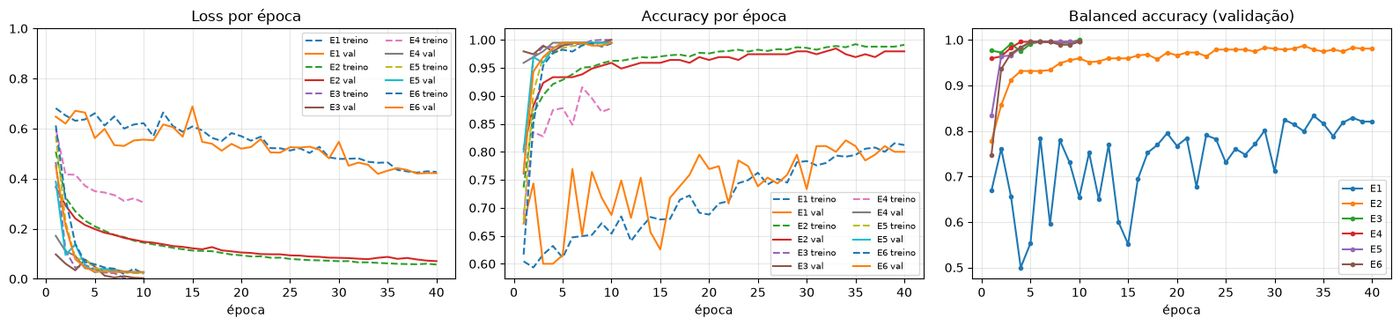

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for k, h in histories.items():
    axes[0].plot(h.epoch, h.train_loss, "--", label=f"{k} treino"); axes[0].plot(h.epoch, h.val_loss, "-", label=f"{k} val")
    axes[1].plot(h.epoch, h.train_acc, "--", label=f"{k} treino"); axes[1].plot(h.epoch, h.val_acc, "-", label=f"{k} val")
    axes[2].plot(h.epoch, h.val_bacc, "-o", ms=3, label=k)
axes[0].set_title("Loss por época"); axes[1].set_title("Accuracy por época"); axes[2].set_title("Balanced accuracy (validação)")
for a in axes: a.set_xlabel("época"); a.grid(alpha=.3)
axes[0].set_ylim(0, 1.0); axes[0].legend(fontsize=7, ncol=2); axes[1].legend(fontsize=7, ncol=2); axes[2].legend(fontsize=8)
plt.tight_layout(); savefig("03_curvas_experimentos"); plt.show()

## 6. Avaliação final no teste (modelo escolhido pela validação)

O critério é a maior *balanced accuracy* de validação; em empate, a menor loss de validação. A escolha é feita **entre os ViTs (E1–E4)**. Para efeito de comparação, a tabela abaixo também reporta o teste de todos os experimentos. A seleção não usa o teste.

In [20]:
best_key = max(["E1", "E2", "E3", "E4"], key=lambda k: (results[k]["bacc"], -results[k]["loss"]))
best_model = models[best_key].to(DEVICE).eval()
print("modelo escolhido:", results[best_key]["name"])
m_test, p_test, y_test = evaluate(best_model, loader("test", tf_eval))
pred_test = (p_test >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred_test)
print({k: round(float(v), 4) for k, v in m_test.items()})
print(classification_report(y_test, pred_test, target_names=CLASSES, digits=4))
tn, fp, fn, tp = cm.ravel()
print(f"peças defeituosas que escapariam (FN): {fn} de {fn + tp} | peças OK refugadas (FP): {fp} de {fp + tn}")

modelo escolhido: E3 fine-tuning


{'loss': 0.0032, 'acc': 1.0, 'bacc': 1.0, 'recall_def': 1.0, 'auc': 1.0}
              precision    recall  f1-score   support

    ok_front     1.0000    1.0000    1.0000        78
   def_front     1.0000    1.0000    1.0000       117

    accuracy                         1.0000       195
   macro avg     1.0000    1.0000    1.0000       195
weighted avg     1.0000    1.0000    1.0000       195

peças defeituosas que escapariam (FN): 0 de 117 | peças OK refugadas (FP): 0 de 78


In [21]:
test_rows = {}
for k, mdl in models.items():
    mt, pt, _ = evaluate(mdl.to(DEVICE), loader("test", tf_eval)); mdl.cpu()
    prt = (pt >= 0.5).astype(int)
    test_rows[k] = dict(experimento=results[k]["name"], parâmetros_treináveis=results[k]["trainable_params"], val_bal_acc=results[k]["bacc"],
                        teste_acc=mt["acc"], teste_bal_acc=mt["bacc"], teste_recall_defeito=mt["recall_def"], teste_AUC=mt["auc"],
                        escapes_FN=int(((prt == 0) & (y_test == 1)).sum()), refugos_FP=int(((prt == 1) & (y_test == 0)).sum()))
    torch.cuda.empty_cache()
best_model = models[best_key].to(DEVICE).eval()
cmp_test = pd.DataFrame(test_rows).T
cmp_test.to_csv(FIG_DIR / "comparacao_teste.csv"); cmp_test.round(4)

,experimento,parâmetros_treináveis,val_bal_acc,teste_acc,teste_bal_acc,teste_recall_defeito,teste_AUC,escapes_FN,refugos_FP
E1,E1 do zero,2855618,0.833333,0.784615,0.799145,0.726496,0.856673,32,10
E2,E2 linear probe,1538,0.987179,0.969231,0.972222,0.957265,0.993754,5,1
E3,E3 fine-tuning,85800194,1.0,1.0,1.0,1.0,1.0,0,0
E4,E4 fine-tuning + CutMix,85800194,0.995726,0.989744,0.991453,0.982906,0.999233,2,0
E5,E5 Swin-T fine-tuning,27520892,0.995726,0.989744,0.991453,0.982906,0.998904,2,0
E6,E6 ResNet-50 fine-tuning,23512130,0.995726,0.994872,0.995726,0.991453,1.0,1,0


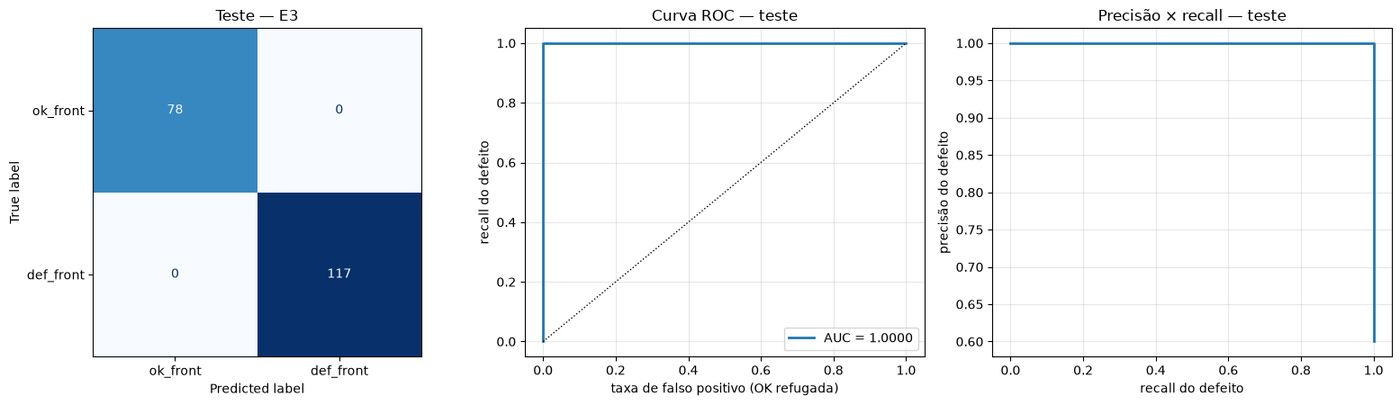

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax[0], cmap="Blues", colorbar=False); ax[0].set_title(f"Teste — {best_key}")
fpr, tpr, thr = roc_curve(y_test, p_test)
ax[1].plot(fpr, tpr, lw=2, label=f"AUC = {m_test['auc']:.4f}"); ax[1].plot([0, 1], [0, 1], "k:", lw=1)
ax[1].set_xlabel("taxa de falso positivo (OK refugada)"); ax[1].set_ylabel("recall do defeito"); ax[1].set_title("Curva ROC — teste"); ax[1].legend()
pr, rc, th = precision_recall_curve(y_test, p_test)
ax[2].plot(rc, pr, lw=2); ax[2].set_xlabel("recall do defeito"); ax[2].set_ylabel("precisão do defeito"); ax[2].set_title("Precisão × recall — teste")
for a in ax[1:]: a.grid(alpha=.3)
plt.tight_layout(); savefig("04_teste_confusao_roc_pr"); plt.show()

### Escolha do limiar de decisão

Em inspeção de qualidade os erros não custam o mesmo: deixar passar uma peça defeituosa (FN) é mais caro que refugar uma peça boa (FP). O procedimento correto seria **escolher o limiar na validação** para um recall-alvo — mas aqui a validação está **saturada** (o modelo escolhido acerta 100% dela), então qualquer limiar entre as menores probabilidades das defeituosas e as maiores das OK "funciona" na validação, e a escolha vira arbitrária. Por isso mostramos o *trade-off* no teste para limiares fixos, deixando explícito que um limiar operacional exigiria uma validação maior.

In [23]:
rows = []
for thr in [0.5, 0.2, 0.05, 0.01, 0.001]:
    pt = (p_test >= thr).astype(int)
    rows.append(dict(limiar=thr, recall_defeito=(pt[y_test == 1] == 1).mean(), defeitos_escapados=int(((pt == 0) & (y_test == 1)).sum()),
                     ok_refugadas=int(((pt == 1) & (y_test == 0)).sum())))
print("probabilidade p(def) das peças defeituosas que o modelo erra em 0,5:", np.round(np.sort(p_test[(y_test == 1) & (p_test < 0.5)]), 4))
pd.DataFrame(rows).round(4)

probabilidade p(def) das peças defeituosas que o modelo erra em 0,5: []


,limiar,recall_defeito,defeitos_escapados,ok_refugadas
0,0.500,1.0,0,0
1,0.200,1.0,0,1
2,0.050,1.0,0,2
3,0.010,1.0,0,6
4,0.001,1.0,0,13


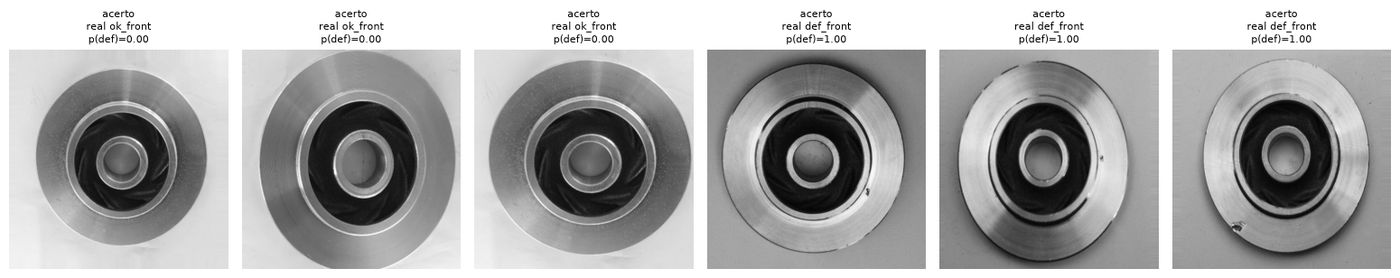

In [24]:
test_df = splits["test"].assign(p_def=p_test, pred=pred_test)
err = test_df[test_df.pred != test_df.y]
ok_conf = test_df[test_df.pred == test_df.y].sort_values("p_def")
show = pd.concat([err, ok_conf.head(3), ok_conf.tail(3)])
fig, axes = plt.subplots(1, len(show), figsize=(2.6 * len(show), 3.2), squeeze=False)
for a, (_, r) in zip(axes[0], show.iterrows()):
    a.imshow(Image.open(r.path).convert("RGB")); a.axis("off")
    a.set_title(f"{'ERRO' if r.pred != r.y else 'acerto'}\nreal {r.label}\np(def)={r.p_def:.2f}", fontsize=8, color="red" if r.pred != r.y else "black")
plt.tight_layout(); savefig("05_erros_e_acertos"); plt.show()

## 7. Visualização dos pesos de atenção

Como o ViT é nosso, basta pedir `return_attn=True` no forward: cada bloco devolve a matriz `A = softmax(QKᵀ/√d_k)` com forma `[B, 12 cabeças, 197, 197]`. A linha 0 é o token [CLS]; `A[:, h, 0, 1:]` é **quanto o [CLS] da cabeça *h* pondera cada um dos 196 patches** — reorganizado em 14×14, ampliado por interpolação bilinear para 224×224 e sobreposto à imagem (Aula 05/08).

Também calculamos o **attention rollout** (Aula 04): multiplica as matrizes de atenção de todas as camadas (média das cabeças + identidade, para modelar a conexão residual) e mostra o fluxo total de informação dos patches até o [CLS].

In [25]:
@torch.no_grad()
def get_attn(model, paths):
    model = model.to(DEVICE).eval()
    x = torch.stack([tf_eval(Image.open(p).convert("RGB")) for p in paths]).to(DEVICE)
    logits, attns = model(x, return_attn=True)
    return torch.softmax(logits, 1)[:, 1].cpu().numpy(), [a.float().cpu() for a in attns]   # L × [B, h, 197, 197]

def cls_map(a):               # [h, 197, 197] ou [197, 197] → mapa 14×14 do [CLS]
    m = a[..., 0, 1:]
    return m.reshape(*m.shape[:-1], 14, 14)

def rollout(attns, b):
    R = torch.eye(197)
    for a in attns:
        A = a[b].mean(0); A = 0.5 * A + 0.5 * torch.eye(197); A = A / A.sum(-1, keepdim=True)
        R = A @ R
    return R[0, 1:].reshape(14, 14)

def upsample(m, size=224):
    m = torch.as_tensor(m)[None, None].float()
    m = F.interpolate(m, size=(size, size), mode="bilinear", align_corners=False)[0, 0].numpy()
    return (m - m.min()) / (m.max() - m.min() + 1e-8)

def show_overlay(ax, path, m, title=None):
    img = np.asarray(Image.open(path).convert("RGB").resize((224, 224)))
    ax.imshow(img); ax.imshow(upsample(m), cmap="jet", alpha=0.5); ax.axis("off")
    if title: ax.set_title(title, fontsize=8)

defect_paths = test_df[(test_df.y == 1) & (test_df.pred == 1)].sort_values("p_def", ascending=False).path.head(4).tolist()
ok_paths = test_df[(test_df.y == 0) & (test_df.pred == 0)].sort_values("p_def").path.head(2).tolist()
viz_paths = defect_paths + ok_paths
p_viz, A_ft = get_attn(best_model, viz_paths)
_, A_pre = get_attn(pre_vit, viz_paths)

### 7.1 ViT treinado do zero (E1): quais regiões emergem?

O ViT pequeno (6 blocos, 3 cabeças) treinado **só com as 910 imagens** também produz pesos de atenção. Mostramos a atenção do [CLS] em cada uma das 3 cabeças da última camada (bloco 6), a média do bloco 3 e o rollout, nas mesmas peças usadas para o modelo pré-treinado.

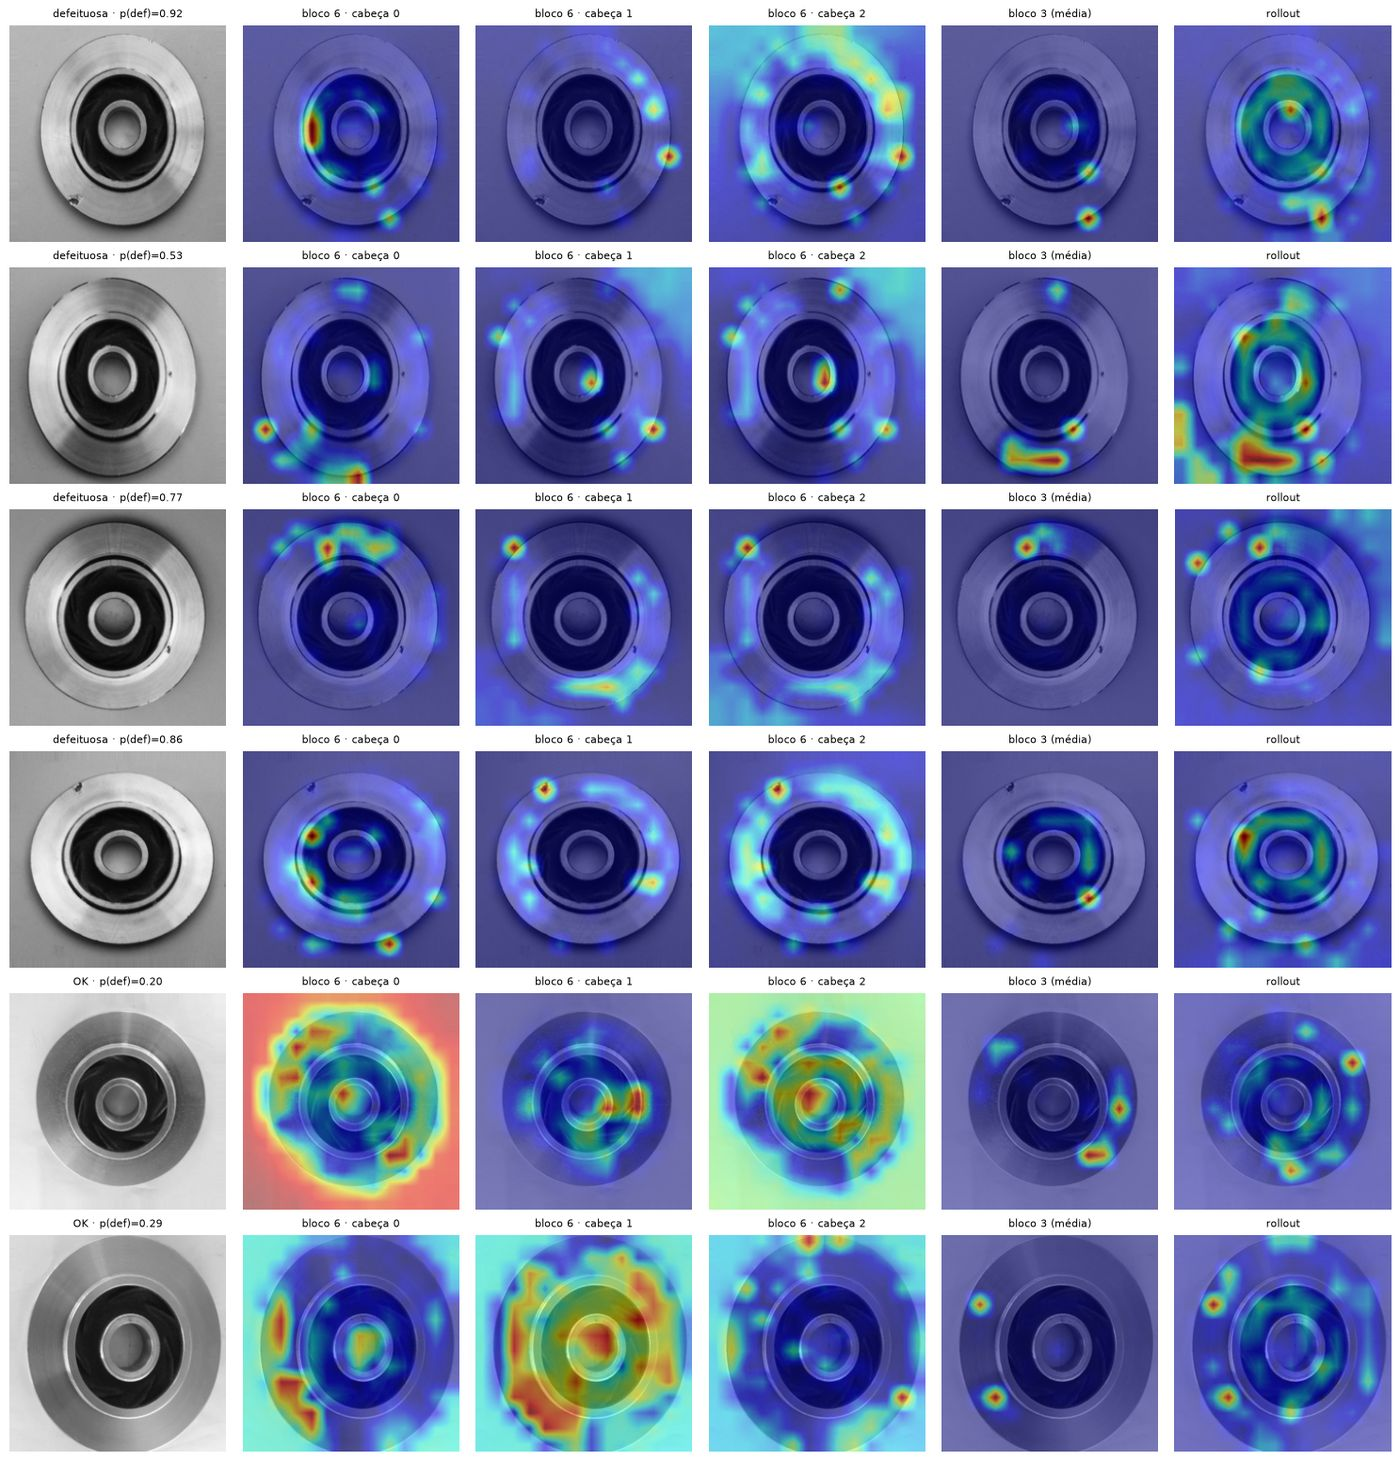

In [26]:
p_sc, A_sc = get_attn(models["E1"], viz_paths)
nL = len(A_sc)
fig, axes = plt.subplots(len(viz_paths), 6, figsize=(15, 2.6 * len(viz_paths)))
for i, p_ in enumerate(viz_paths):
    axes[i, 0].imshow(load_img(p_)); axes[i, 0].axis("off")
    axes[i, 0].set_title(("defeituosa" if i < len(defect_paths) else "OK") + f" · p(def)={p_sc[i]:.2f}", fontsize=8)
    for h in range(3):
        show_overlay(axes[i, h + 1], p_, cls_map(A_sc[-1][i])[h], f"bloco {nL} · cabeça {h}")
    show_overlay(axes[i, 4], p_, cls_map(A_sc[nL // 2 - 1][i]).mean(0), f"bloco {nL // 2} (média)")
    show_overlay(axes[i, 5], p_, rollout(A_sc, i), "rollout")
plt.tight_layout(); savefig("06a_atencao_vit_do_zero"); plt.show()

### 7.2 As 12 cabeças da última camada (uma peça defeituosa)

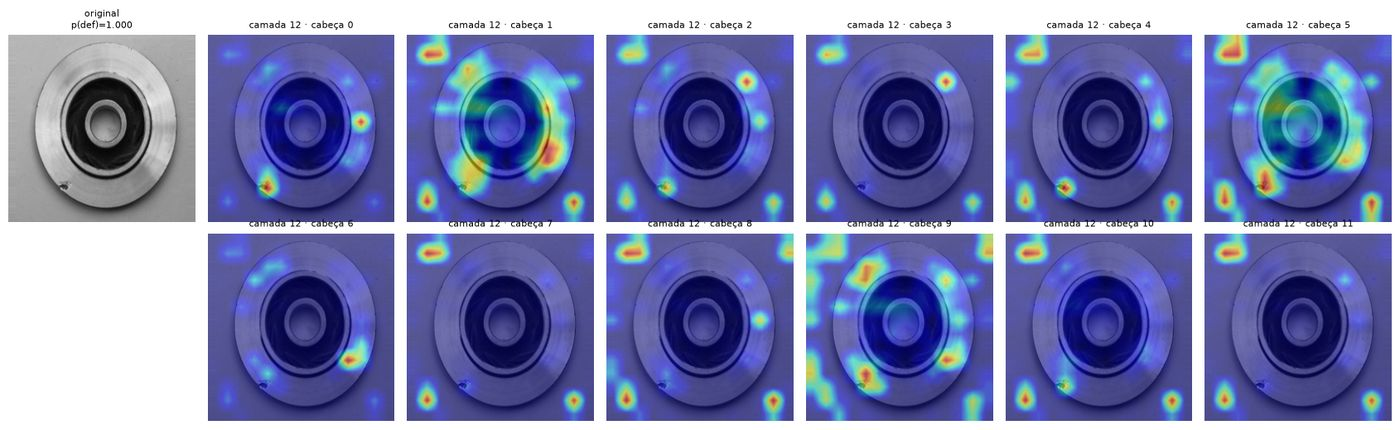

In [27]:
b = 0
fig, axes = plt.subplots(2, 7, figsize=(17, 5.2))
axes[0, 0].imshow(Image.open(viz_paths[b]).convert("RGB").resize((224, 224))); axes[0, 0].set_title(f"original\np(def)={p_viz[b]:.3f}", fontsize=8); axes[0, 0].axis("off")
axes[1, 0].axis("off")
heads_last = cls_map(A_ft[-1][b])
for h in range(12):
    show_overlay(axes.ravel()[1 + h + (1 if h >= 6 else 0)], viz_paths[b], heads_last[h], f"camada 12 · cabeça {h}")
plt.tight_layout(); savefig("06_atencao_12_cabecas_ultima_camada"); plt.show()

### 7.3 Uma cabeça, várias peças: defeituosas vs OK

Escolhemos a cabeça da última camada **mais concentrada** (menor entropia média da atenção do [CLS] nas peças defeituosas) e a mostramos em todas as imagens selecionadas, antes (ImageNet) e depois do fine-tuning.

entropia média por cabeça (camada 12, peças defeituosas): [4.24 4.51 3.96 3.81 3.47 4.58 3.8  3.07 3.71 4.4  4.   3.35]
cabeça mais concentrada: 7 | entropia máxima possível = ln(196) = 5.28


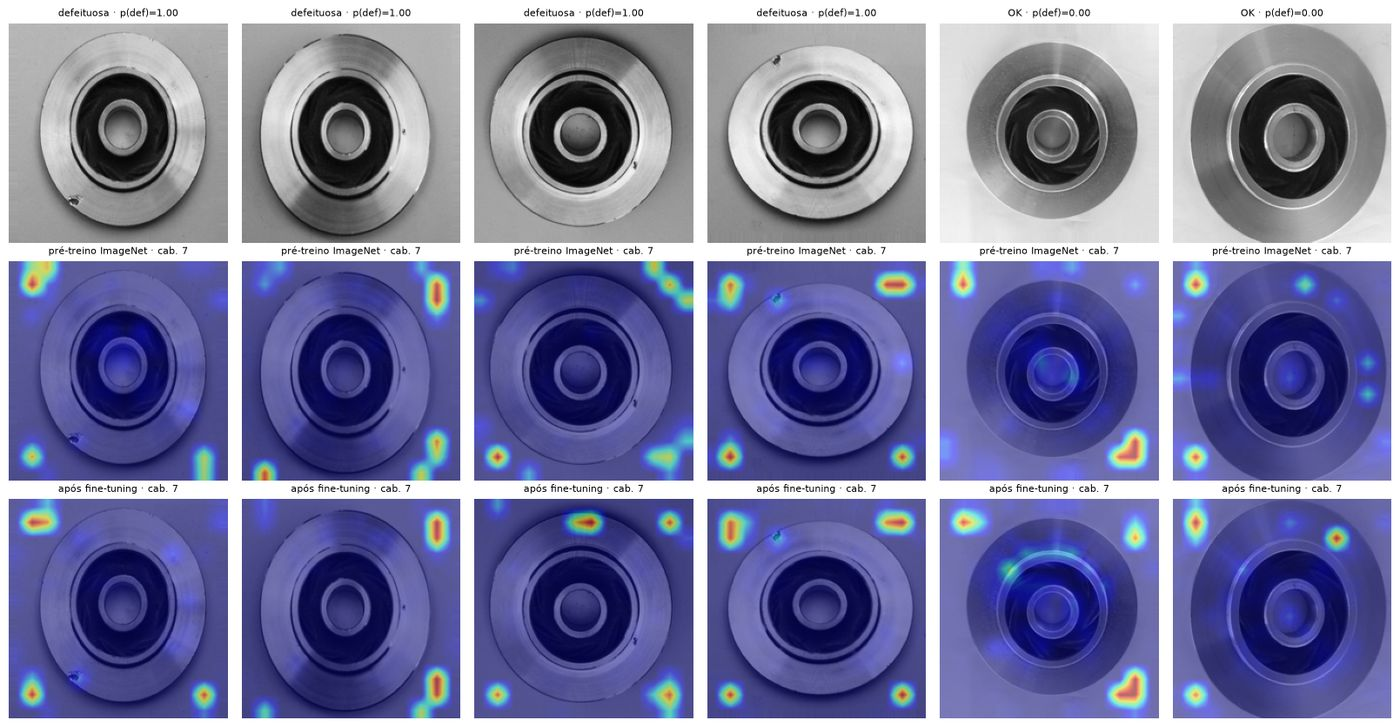

In [28]:
def entropy(m):               # entropia (nats) da distribuição de atenção do [CLS] sobre os patches
    p = m / m.sum(-1, keepdim=True)
    return -(p * (p + 1e-12).log()).sum(-1)

cls_last = A_ft[-1][:, :, 0, 1:]                       # [B, h, 196]
ent = entropy(cls_last)                                # [B, h]
head_star = int(ent[:len(defect_paths)].mean(0).argmin())
print("entropia média por cabeça (camada 12, peças defeituosas):", ent[:len(defect_paths)].mean(0).numpy().round(2))
print("cabeça mais concentrada:", head_star, "| entropia máxima possível = ln(196) =", round(math.log(196), 2))

fig, axes = plt.subplots(3, len(viz_paths), figsize=(2.7 * len(viz_paths), 8.4))
for j, p in enumerate(viz_paths):
    lab = "defeituosa" if j < len(defect_paths) else "OK"
    axes[0, j].imshow(Image.open(p).convert("RGB").resize((224, 224))); axes[0, j].axis("off"); axes[0, j].set_title(f"{lab} · p(def)={p_viz[j]:.2f}", fontsize=8)
    show_overlay(axes[1, j], p, cls_map(A_pre[-1][j])[head_star], f"pré-treino ImageNet · cab. {head_star}")
    show_overlay(axes[2, j], p, cls_map(A_ft[-1][j])[head_star], f"após fine-tuning · cab. {head_star}")
plt.tight_layout(); savefig("07_cabeca_escolhida_antes_depois"); plt.show()

### 7.4 Profundidade: camadas 1, 6 e 12 (média das cabeças) e rollout

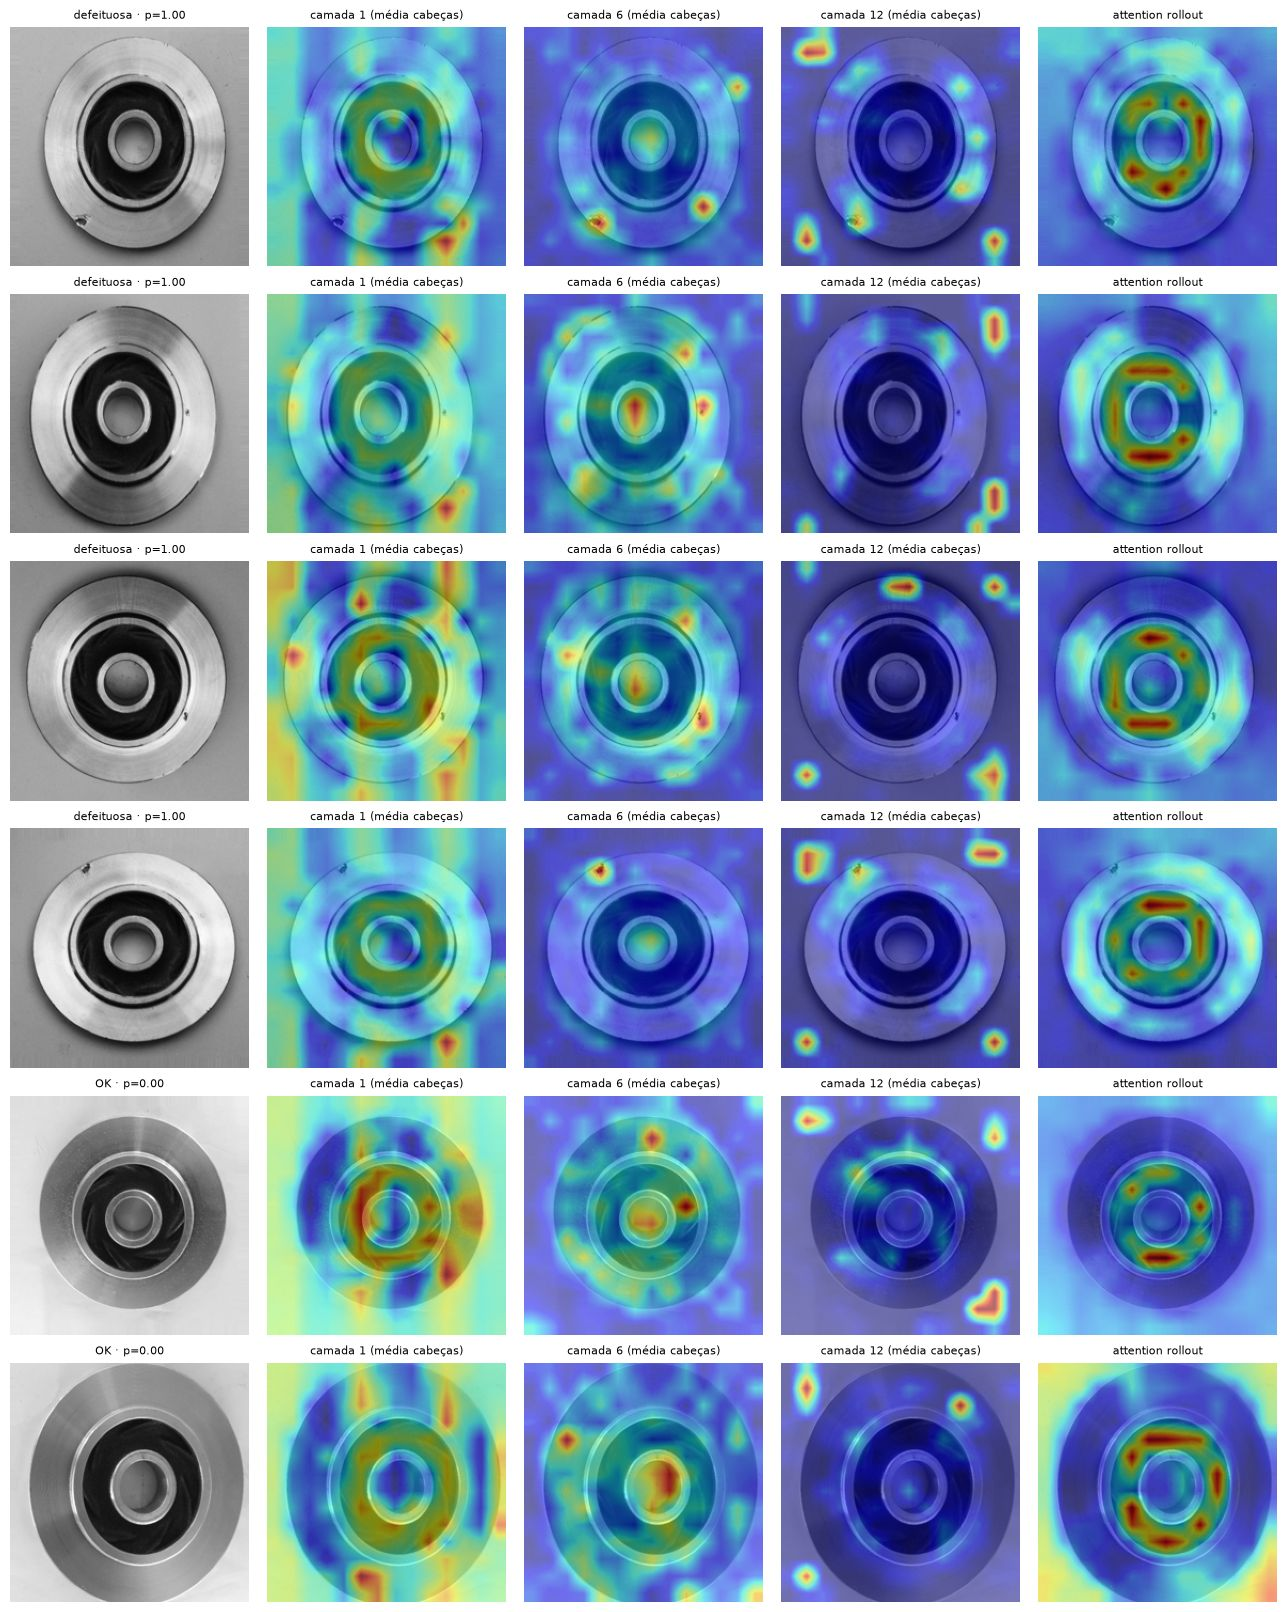

In [29]:
fig, axes = plt.subplots(len(viz_paths), 5, figsize=(13, 2.7 * len(viz_paths)))
for i, p in enumerate(viz_paths):
    axes[i, 0].imshow(Image.open(p).convert("RGB").resize((224, 224))); axes[i, 0].axis("off")
    axes[i, 0].set_title(("defeituosa" if i < len(defect_paths) else "OK") + f" · p={p_viz[i]:.2f}", fontsize=8)
    for k, L in enumerate([0, 5, 11]):
        show_overlay(axes[i, k + 1], p, cls_map(A_ft[L][i]).mean(0), f"camada {L+1} (média cabeças)")
    show_overlay(axes[i, 4], p, rollout(A_ft, i), "attention rollout")
plt.tight_layout(); savefig("08_atencao_por_camada_e_rollout"); plt.show()

### 7.5 Medindo onde a atenção cai (todo o conjunto de teste)

Para não depender de exemplos escolhidos a dedo, medimos em **todas** as imagens de teste:
- **perfil radial** da atenção do [CLS] (cabeça escolhida, última camada): a peça é circular e centrada, então a distância ao centro separa cubo central, pás, anel externo (onde ficam rebarbas e falhas de borda) e fundo;
- **fração da atenção no fundo** (cantos, fora do disco da peça) — se for alta, o modelo estaria usando o fundo como atalho;
- **entropia** de cada cabeça e número de patches acima de média + 2σ (Aula 08).

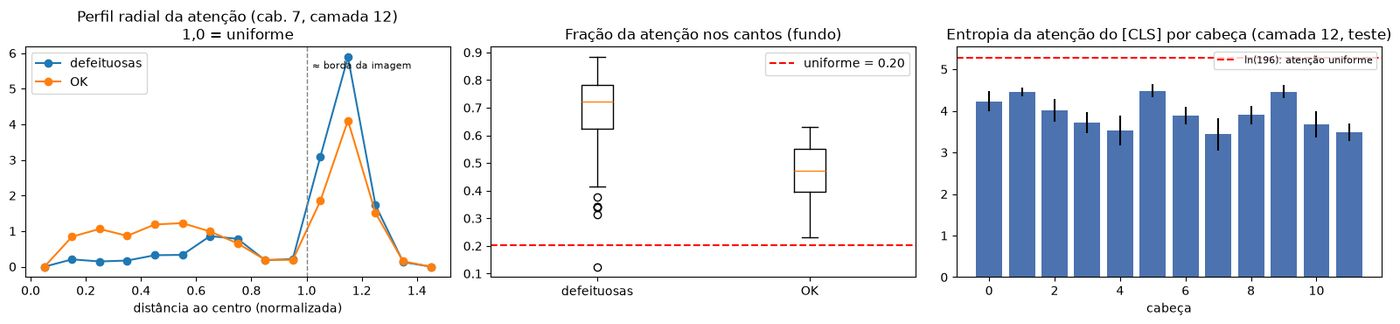

patches acima de média+2σ por cabeça (média no teste): [ 9.1 10.5 10.1  6.4  8.4 10.9  9.6  6.8  8.1 11.3  6.9  7.1]
atenção no fundo — defeituosas: 0.686 | OK: 0.467 | uniforme: 0.204


In [30]:
@torch.no_grad()
def attn_stats(model, split):
    model = model.to(DEVICE).eval(); out = []
    yy, xx = np.mgrid[0:14, 0:14]; r = np.sqrt((yy - 6.5) ** 2 + (xx - 6.5) ** 2) / 7.0     # raio normalizado por patch
    for x, y in loader(split, tf_eval, bs=16):
        x = x.to(DEVICE)
        with torch.autocast(device_type="cuda", enabled=DEVICE == "cuda"):
            _, attns = model(x, return_attn=True)
        a = attns[-1].float()[:, :, 0, 1:].cpu()               # [B, h, 196]
        for i in range(len(y)):
            m = a[i, head_star].numpy().reshape(14, 14); m = m / m.sum()
            ent_h = entropy(a[i]).numpy()
            mu, sd = a[i].mean(-1, keepdim=True), a[i].std(-1, keepdim=True)
            out.append(dict(y=int(y[i]), radial=[m[(r >= lo) & (r < lo + 0.1)].sum() for lo in np.arange(0, 1.5, 0.1)],
                            fundo=float(m[r > 1.0].sum()), entropia=ent_h, picos=(a[i] > mu + 2 * sd).sum(-1).numpy()))
    return out, r

stats, R = attn_stats(best_model, "test")
radial = np.array([s["radial"] for s in stats]); ys = np.array([s["y"] for s in stats])
area = np.array([((R >= lo) & (R < lo + 0.1)).sum() for lo in np.arange(0, 1.5, 0.1)])
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
centers = np.arange(0, 1.5, 0.1) + 0.05
for k, lab in [(1, "defeituosas"), (0, "OK")]:
    ax[0].plot(centers, (radial[ys == k] / np.maximum(area, 1)).mean(0) * 196, "o-", label=lab)
ax[0].axvline(1.0, color="gray", ls="--", lw=1); ax[0].text(1.02, ax[0].get_ylim()[1] * .9, "≈ borda da imagem", fontsize=8)
ax[0].set_title(f"Perfil radial da atenção (cab. {head_star}, camada 12)\n1,0 = uniforme"); ax[0].set_xlabel("distância ao centro (normalizada)"); ax[0].legend()
fundo = np.array([s["fundo"] for s in stats])
ax[1].boxplot([fundo[ys == 1], fundo[ys == 0]]); ax[1].set_xticks([1, 2], ["defeituosas", "OK"])
ax[1].axhline((R > 1.0).mean(), color="red", ls="--", label=f"uniforme = {(R > 1.0).mean():.2f}"); ax[1].legend()
ax[1].set_title("Fração da atenção nos cantos (fundo)")
E = np.stack([s["entropia"] for s in stats]); ax[2].bar(range(12), E.mean(0), yerr=E.std(0), color="#4C72B0")
ax[2].axhline(math.log(196), color="red", ls="--", label="ln(196): atenção uniforme"); ax[2].legend(fontsize=8)
ax[2].set_title("Entropia da atenção do [CLS] por cabeça (camada 12, teste)"); ax[2].set_xlabel("cabeça")
plt.tight_layout(); savefig("09_atencao_quantitativa"); plt.show()
picos = np.stack([s["picos"] for s in stats])
print("patches acima de média+2σ por cabeça (média no teste):", picos.mean(0).round(1))
print(f"atenção no fundo — defeituosas: {fundo[ys==1].mean():.3f} | OK: {fundo[ys==0].mean():.3f} | uniforme: {(R > 1.0).mean():.3f}")

### 7.6 Camada intermediária: as cabeças da camada 6

Na última camada, várias cabeças concentram a atenção do [CLS] em poucos patches de **fundo** — padrão que já existe no modelo **pré-treinado no ImageNet**, antes do fine-tuning (seção 7.3). Na camada 6, a média das cabeças acende pontos **sobre a peça**. Mostramos as 12 cabeças da camada 6 nas peças defeituosas para localizar quais delas "olham" para o defeito.

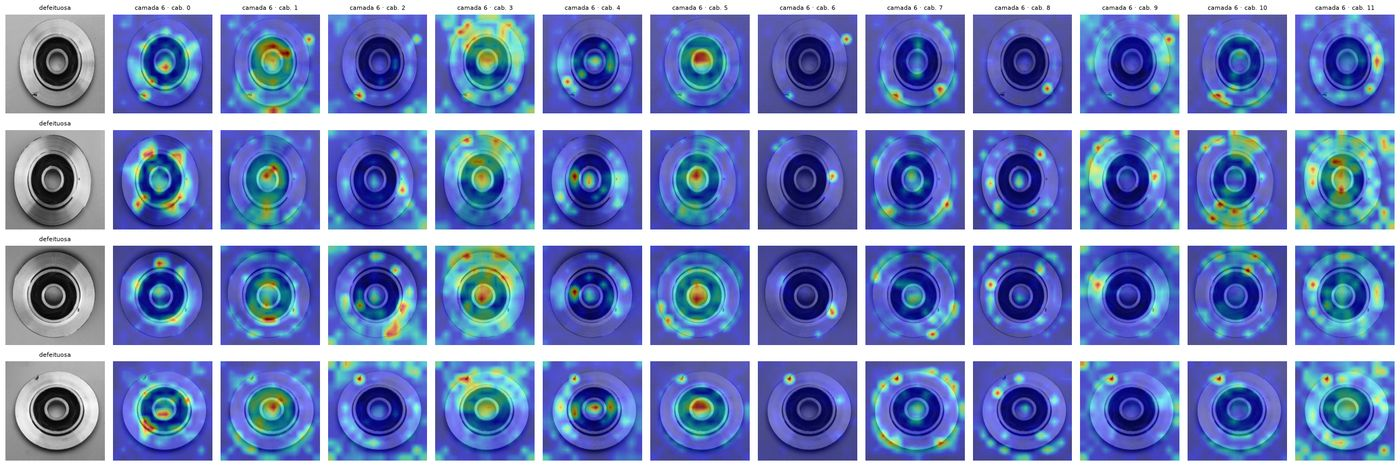

In [31]:
fig, axes = plt.subplots(len(defect_paths), 13, figsize=(26, 2.2 * len(defect_paths)))
for i, p in enumerate(defect_paths):
    axes[i, 0].imshow(Image.open(p).convert("RGB").resize((224, 224))); axes[i, 0].axis("off"); axes[i, 0].set_title("defeituosa", fontsize=8)
    hm = cls_map(A_ft[5][i])
    for h in range(12):
        show_overlay(axes[i, h + 1], p, hm[h], f"camada 6 · cab. {h}" if i == 0 else None)
plt.tight_layout(); savefig("10_camada6_cabecas_defeitos"); plt.show()

### 7.7 O modelo usa o fundo como atalho? Teste contrafactual

A seção 1 mostrou que o **tipo de fundo está correlacionado com a classe**: 79% das peças defeituosas foram fotografadas sobre fundo cinza e 73% das OK sobre fundo branco. Um classificador poderia acertar boa parte só olhando o fundo — e a atenção da última camada cai bastante nos cantos. Dois testes:

1. **Desempenho por subgrupo** (classe × fundo) no teste: se o modelo usa o fundo, erra mais nos casos "contra a correlação" (defeituosa em fundo branco, OK em fundo cinza).
2. **Contrafactual:** pintamos os **cantos** da imagem (fora do círculo inscrito, onde só há fundo) de **branco** e depois de **cinza**, sem tocar na peça, e medimos quantas predições mudam. Se o modelo olha a peça, trocar a cor dos cantos não deveria alterar nada.

In [32]:
sub = test_df.assign(acerto=(test_df.pred == test_df.y)).groupby(["label", "fundo_tipo"]).agg(n=("y", "size"), accuracy=("acerto", "mean"),
                                                                                            p_def_media=("p_def", "mean"))
print("Desempenho no teste por subgrupo (classe × fundo):"); print(sub.round(4).to_string())
print("\nDefeituosas não detectadas (FN):"); print(test_df[(test_df.y == 1) & (test_df.pred == 0)][["fundo_tipo", "fundo", "p_def"]].round(3).to_string())

gray_level = int(df[df.fundo_tipo == "cinza"].fundo.median()); white_level = int(df[df.fundo_tipo == "branco"].fundo.median())
yy, xx = np.mgrid[0:224, 0:224]; corner_mask = np.sqrt((yy - 111.5) ** 2 + (xx - 111.5) ** 2) > 112

def paint_corners(img, level):
    a = np.asarray(img).copy(); a[corner_mask] = level
    return Image.fromarray(a)

@torch.no_grad()
def predict_paths(model, paths, fn=None):
    model = model.to(DEVICE).eval(); P = []
    for i in range(0, len(paths), 32):
        imgs = [load_img(p) for p in paths[i:i + 32]]
        x = torch.stack([tf_eval(fn(im) if fn else im) for im in imgs]).to(DEVICE)
        with torch.autocast(device_type="cuda", enabled=DEVICE == "cuda"):
            P.append(torch.softmax(model(x).float(), 1)[:, 1].cpu())
    return torch.cat(P).numpy()

paths_te = test_df.path.tolist()
cf = {"original": predict_paths(best_model, paths_te),
      f"cantos brancos ({white_level})": predict_paths(best_model, paths_te, lambda im: paint_corners(im, white_level)),
      f"cantos cinza ({gray_level})": predict_paths(best_model, paths_te, lambda im: paint_corners(im, gray_level))}
rows = []
for k, p in cf.items():
    pr_ = (p >= 0.5).astype(int)
    rows.append(dict(cenário=k, accuracy=(pr_ == y_test).mean(), recall_defeito=(pr_[y_test == 1] == 1).mean(),
                     especificidade=(pr_[y_test == 0] == 0).mean(), predições_alteradas=int((pr_ != (cf["original"] >= 0.5)).sum()),
                     p_def_media_OK=p[y_test == 0].mean(), p_def_media_defeituosas=p[y_test == 1].mean()))
cf_tab = pd.DataFrame(rows); cf_tab.round(4)

Desempenho no teste por subgrupo (classe × fundo):
                       n  accuracy  p_def_media
label     fundo_tipo                           
def_front branco      25       1.0       0.9946
          cinza       92       1.0       0.9999
ok_front  branco      57       1.0       0.0074
          cinza       21       1.0       0.0004

Defeituosas não detectadas (FN):
Empty DataFrame
Columns: [fundo_tipo, fundo, p_def]
Index: []


,cenário,accuracy,recall_defeito,especificidade,predições_alteradas,p_def_media_OK,p_def_media_defeituosas
0,original,1.0000,1.0000,1.0,0,0.0056,0.9988
1,cantos brancos (218),0.9744,0.9573,1.0,5,0.0003,0.9517
2,cantos cinza (157),0.9795,0.9658,1.0,4,0.0003,0.9680


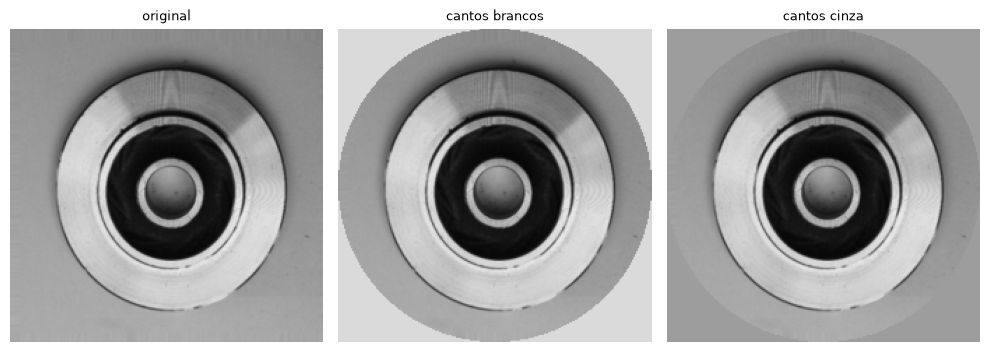

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
ex = test_df[(test_df.y == 1)].path.iloc[0]
for a, (t, im) in zip(axes, [("original", load_img(ex)), ("cantos brancos", paint_corners(load_img(ex), white_level)),
                             ("cantos cinza", paint_corners(load_img(ex), gray_level))]):
    a.imshow(im); a.set_title(t, fontsize=9); a.axis("off")
plt.tight_layout(); savefig("11_contrafactual_fundo_exemplo"); plt.show()

## 8. Resultados consolidados

In [34]:
summary = dict(modelo_escolhido=results[best_key]["name"], comparacao_teste=cmp_test.round(4).to_dict("index"), positional_encoding=pe_tab.round(6).to_dict("records"), validacao={k: {kk: (round(float(vv), 4) if isinstance(vv, (float, np.floating)) else vv)
               for kk, vv in v.items()} for k, v in results.items()},
               teste={k: round(float(v), 4) for k, v in m_test.items()}, matriz_confusao_teste=cm.tolist(),
               cabeca_visualizada=head_star, fracao_atencao_fundo=dict(defeituosas=float(fundo[ys == 1].mean()), ok=float(fundo[ys == 0].mean())),
               contrafactual_fundo=cf_tab.round(4).to_dict("records"), subgrupos_teste=sub.round(4).reset_index().to_dict("records"))
(FIG_DIR / "results.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
print(json.dumps(summary, indent=2, ensure_ascii=False, default=str))

{
  "modelo_escolhido": "E3 fine-tuning",
  "comparacao_teste": {
    "E1": {
      "experimento": "E1 do zero",
      "parâmetros_treináveis": 2855618,
      "val_bal_acc": 0.8333333333333334,
      "teste_acc": 0.7846153846153846,
      "teste_bal_acc": 0.7991452991452992,
      "teste_recall_defeito": 0.7264957264957265,
      "teste_AUC": 0.8566732412886259,
      "escapes_FN": 32,
      "refugos_FP": 10
    },
    "E2": {
      "experimento": "E2 linear probe",
      "parâmetros_treináveis": 1538,
      "val_bal_acc": 0.9871794871794872,
      "teste_acc": 0.9692307692307692,
      "teste_bal_acc": 0.9722222222222223,
      "teste_recall_defeito": 0.9572649572649573,
      "teste_AUC": 0.9937541091387245,
      "escapes_FN": 5,
      "refugos_FP": 1
    },
    "E3": {
      "experimento": "E3 fine-tuning",
      "parâmetros_treináveis": 85800194,
      "val_bal_acc": 1.0,
      "teste_acc": 1.0,
      "teste_bal_acc": 1.0,
      "teste_recall_defeito": 1.0,
      "teste_AUC": 1.0,

## 9. Análise e justificativa técnica

### 9.1 Por que esta arquitetura para este domínio

- **ViT-B/16 pré-treinado e ajustado por fine-tuning**, e não um ViT do zero: a Aula 04 mostra que o ViT tem viés indutivo quase nulo e "fome de dados". Com 910 imagens de treino, o experimento confirma isso de forma clara:
  - **E1 (ViT pequeno do zero):** balanced accuracy de validação de **0,83**, e no teste **78,5%** de accuracy, com 32 defeitos escapando.
  - **E2 (mesmo ViT-B/16 congelado + cabeça linear de 1.538 parâmetros):** **0,987** na validação e 97,2% de balanced accuracy no teste. As features do ImageNet já separam quase tudo.
  - **E3 (fine-tuning completo):** **1,000** na validação e **100% no teste**.

  O pré-treino vale mais do que qualquer ajuste de hiperparâmetro do modelo do zero.
- **Por que fine-tuning completo e não só *linear probe*:** o E2 é forte, mas deixa escapar 5 das 117 defeituosas no teste. O fine-tuning adapta as camadas intermediárias às texturas de metal fundido (rebarbas, porosidade, falhas de borda), que não existem no ImageNet. Com LR baixo no backbone (3e-5), isso acontece sem *catastrophic forgetting*, com convergência estável.
- **Por que ViT:** a análise com dados está em 9.7. Em resumo, com pré-treino o ViT empata com a CNN e com o Swin, e oferece explicabilidade nativa: os pesos de atenção saem do próprio forward, sem gradientes. O defeito pode estar em qualquer ponto do anel, e a atenção global pondera todos os patches desde a primeira camada.

### 9.2 Por que esses hiperparâmetros

| Hiperparâmetro | Valor | Justificativa |
|---|---|---|
| LR do backbone / cabeça | 3e-5 / 1e-3 | Faixa 2e-5–5e-5 para não destruir o pré-treino (Aula 03). A cabeça nova parte do zero e precisa de LR maior (Aula 08). |
| Warmup + cosine | 1 época + cosine | Protege o backbone dos gradientes grandes da cabeça aleatória no início. |
| Épocas | 10 | A validação satura (100%) antes do fim. Mais épocas só aumentariam o risco de overfitting. |
| Weight decay / clipping | 0,05 / 1,0 | Regularização padrão de fine-tuning de ViT. |
| Batch efetivo | 32 (micro-batch 16 + acumulação em GPU de 6 GB) | Mantém a dinâmica de otimização igual no T4 e em GPUs menores. |
| Augmentation | Grupo D4 + brilho/contraste | Peça circular vista de cima: rotação e espelhamento preservam o rótulo e são **sem perda** (não criam cantos pretos). |
| CutMix | **não** (E4 como ablação) | Ver 9.3. |

### 9.3 O que os resultados revelam

- **Teste (modelo E3, escolhido pela validação):** accuracy, balanced accuracy, recall de defeito e AUC de **100%**. **Nenhuma peça defeituosa escapa e nenhuma peça boa é refugada** entre as 195 do teste. Como a validação também está saturada, o limiar 0,5 não pode ser refinado com estes dados. Baixá-lo só acrescenta refugos (1 com 0,2; 6 com 0,01). Num teste de 195 imagens, 100% significa "erro abaixo de ~1,5%" (IC de 95%, regra de três), e não "erro zero".
- **CutMix (E4) não ajudou:** 0,996 na validação e 2 escapes no teste, contra 1,000 e 0 escapes do E3. A accuracy de treino ficou bem menor (0,88), porque os rótulos misturados são inconsistentes por construção. A hipótese se sustenta: em detecção de defeito local, o rótulo proporcional à área é semanticamente errado. Uma peça com um retângulo defeituoso colado é defeituosa, não "30% defeituosa". A recomendação da Aula 04 vale para classes cuja evidência se espalha pelo objeto, não para anomalias locais.
- **Subgrupos de fundo:** o E3 acerta 100% nos quatro subgrupos (classe × tipo de fundo). A correlação fundo↔classe não gera erros neste teste. O teste contrafactual (9.4) mostra, porém, uma sensibilidade residual à região do fundo.

### 9.4 O que o modelo aprende a ponderar (atenção)

**ViT pré-treinado e ajustado (E3), por profundidade:**
- **Camada 1 (média das cabeças):** atenção difusa e local, em faixas verticais que acompanham bordas e contrastes. São padrões de baixo nível.
- **Camada 6: é onde os defeitos aparecem.** Várias cabeças da camada 6 (por exemplo 2, 6 e 10) concentram a atenção do [CLS] em **pontos isolados sobre o anel externo** que coincidem com furos e falhas de borda. Na peça com o furo no topo, as cabeças 2, 4, 6, 9, 10 e 11 marcam exatamente o furo. Há divisão de trabalho, como na Aula 05: a cabeça 5 se especializa no **cubo central** e a cabeça 0 contorna o **anel das pás**.
- **Camada 12: defeito + "registradores" no fundo.** Na peça com falha de borda (canto inferior esquerdo da peça), as cabeças **0, 2, 4, 5 e 9** marcam exatamente a falha. Ao mesmo tempo, quase todas as cabeças concentram parte da atenção em 3 a 5 patches nos **cantos da imagem**. A cabeça 7, a mais concentrada (entropia de 3,07 nats contra 5,28 se fosse uniforme), põe **69% da atenção nos cantos** das peças defeituosas e 47% das OK, contra 20% esperados por área. A comparação "antes × depois" mostra que esse padrão **já existe no ViT pré-treinado no ImageNet**. É o fenômeno de Darcet et al. (2024, *Vision Transformers Need Registers*): ViTs supervisionados reaproveitam patches de fundo, de baixa informação, como memória global, e o [CLS] lê ali o resultado agregado.
- **Isso é um atalho? Contrafactual:**
  - Pintando os cantos de **branco**, mudam **5 de 195** predições, com recall de 95,7%.
  - Pintando de **cinza**, mudam **4**, com recall de 96,6%.
  - A especificidade fica intacta nos dois casos.

  Os dois efeitos têm a mesma direção e tamanho parecido, então **a cor do fundo não decide a classe**. Mas apagar a região dos cantos, com qualquer cor, faz o modelo perder alguns defeitos: os "registradores" guardam informação agregada que o [CLS] usa. **Conclusão:** o modelo decide olhando a peça (a camada 6 localiza os defeitos), mas depende da região do fundo como memória. Uma mudança de fundo em produção (outra bancada, outro enquadramento) é um risco real.

**ViT treinado do zero (E1): regiões emergentes.**
- Mesmo com só 910 imagens, surgem **detectores locais**: nas peças defeituosas, as 3 cabeças do bloco 6 produzem pontos nítidos sobre o **anel externo**, e em várias peças (por exemplo, a do furo no topo) caem sobre o defeito. O rollout forma um **anel** em torno do cubo, ou seja, o modelo descobriu sozinho a geometria circular da peça.
- Nas peças OK, porém, a atenção é **difusa e se espalha pelo fundo** (cabeças 0 e 2 cobrem o fundo branco). As probabilidades ficam incertas (0,20–0,29), o que indica uso do **fundo e da iluminação global** como pista, justamente o atalho correlacionado com a classe.
- Sem o pré-treino para "ensinar" a ignorar o fundo, o modelo pequeno mistura evidência local com contexto, e por isso erra 32 defeitos e refuga 10 peças boas.
- O contraste com o E3 resume a atividade: **o pré-treino traz features locais robustas, e o ViT do zero ainda está aprendendo o que é peça e o que é fundo.**
### 9.5 Pré-treino do BERT × pré-treino do ViT: o que cada um maximiza

Os dois são **encoders Transformer quase idênticos** (Aula 03): mesmo bloco Pre-LN, 12 camadas, D = 768, 12 cabeças, token [CLS] e *position embeddings* aprendidos. A diferença está no **objetivo de pré-treino**, ou seja, no que cada um é treinado para maximizar:

| | **BERT** (texto) | **ViT** original (imagem) |
|---|---|---|
| Supervisão | **Auto-supervisionado**: o rótulo é o próprio texto | **Supervisionado**: rótulos humanos de classe (ImageNet-21k / JFT-300M) |
| Objetivo | **MLM**: maximizar `Σ log P(token mascarado | contexto bidirecional)` em 15% dos tokens, + **NSP** (`log P(IsNext)`) | Maximizar `log P(classe | imagem)` (cross-entropy) sobre a saída do [CLS] |
| O que a representação aprende | Contexto e semântica **de cada token** a partir dos vizinhos: sintaxe, co-referência, sentido | Features **discriminativas para a taxonomia de rótulos**: o [CLS] precisa separar classes, e as features ignoram o que não ajuda a classificar |
| Dados | Texto bruto da web (3,3 B palavras), sem anotação | Centenas de milhões de imagens **rotuladas** |
| Uso a jusante | Cabeças plugáveis sobre [CLS] ou tokens, *fine-tuning* com LR 2e-5–5e-5 por 2–4 épocas | Troca da cabeça e *fine-tuning* com LR baixo, como feito no E3 |

**Consequências:**
- O BERT maximiza a **reconstrução do sinal**, e a representação é **genérica** e rica em contexto local. O ViT supervisionado maximiza a **separação de classes**, e a representação é **discriminativa**, mas herda o viés da taxonomia: no ImageNet, "objeto centralizado, fundo irrelevante".
- É por isso que, na última camada do ViT, a atenção do [CLS] vai para poucos patches de **fundo** usados como memória global, o artefato de "registradores" visto na seção 7. O objetivo supervisionado não exige atenção espacialmente interpretável, só um [CLS] separável.
- A versão "BERT da visão" existe e corrige isso: **MAE** e BEiT mascaram 75% dos patches e maximizam a **reconstrução** (Aula 05). O **DINO** maximiza a concordância entre visões (auto-destilação), e seus mapas de atenção segmentam o objeto. O **CLIP** (A2) maximiza o alinhamento imagem–texto (InfoNCE). Com poucos dados, como aqui, um backbone auto-supervisionado (DINOv2 / MAE) tende a dar features mais transferíveis para defeitos, que são texturas fora da taxonomia do ImageNet.

### 9.6 DeiT e Swin: o que resolvem que o ViT original não resolve

A Aula 05 lista três barreiras do ViT original: **fome de dados**, **escala rígida** (uma única grade 14×14) e **custo O(N²)** da atenção global.

- **DeiT (Touvron et al., 2021): resolve a fome de dados.** O ViT original só supera CNNs com pré-treino em JFT-300M (300 M imagens). O DeiT treina o mesmo ViT **só com o ImageNet-1k** usando duas ideias:
  1. **Augmentation e regularização pesadas** (RandAugment, Mixup, CutMix, *stochastic depth*);
  2. **Destilação por token**: um token `[DIST]`, ao lado do [CLS], aprende a imitar uma CNN professora congelada (RegNet). Assim o ViT absorve o viés indutivo de localidade da CNN sem tê-lo na arquitetura. A **destilação hard** (rótulo argmax da professora) funciona melhor que a soft.

  Resultado: top-1 de 79,9% para 85,2% sem dados extras. **Neste domínio**, o DeiT seria a forma de treinar um ViT com poucas peças **sem** depender de um pré-treino gigante: a CNN professora traria a localidade, útil para defeitos pequenos.
- **Swin Transformer (Liu et al., 2021): resolve escala e custo.** O ViT mantém 197 tokens de 16×16 em todas as camadas: não produz uma pirâmide de resoluções (inviável para FPN, detecção e segmentação), e a atenção global custa O(N²), o que dá OOM em alta resolução. O Swin:
  1. Calcula atenção só dentro de **janelas locais** M×M (M = 7), então o custo fica **linear** no número de patches.
  2. **Desloca as janelas** a cada bloco (*shifted windows*, com *cyclic shift* + máscara) para que janelas vizinhas troquem informação.
  3. Faz **patch merging**, que funde patches e dobra os canais a cada estágio (resoluções H/4 → H/32). Com isso tem uma **hierarquia multi-escala**, como uma CNN.

  **Neste domínio**, isso permite usar imagens maiores (512 px, preservando defeitos de poucos pixels) sem explodir a memória, e dá features em várias escalas, úteis para **localizar** o defeito, e não só classificar a peça.

### 9.7 Quando ViT supera CNN, e quando não: evidência neste domínio

| Modelo (mesma receita de fine-tuning) | Parâm. | Tempo de treino | Val. bal. acc | Teste acc | Escapes / refugos (teste) | AUC teste |
|---|---|---|---|---|---|---|
| ViT pequeno **do zero** (E1) | 2,9 M | 133 s | 0,833 | 78,5% | 32 / 10 | 0,857 |
| **ViT-B/16 pré-treinado (E3)** | 85,8 M | 182 s | **1,000** | **100%** | **0 / 0** | **1,000** |
| Swin-T pré-treinado (E5) | 27,5 M | 130 s | 0,996 | 99,0% | 2 / 0 | 0,999 |
| ResNet-50 pré-treinada (E6) | 23,5 M | 92 s | 0,996 | 99,5% | 1 / 0 | 1,000 |

- **Com pré-treino, as três arquiteturas empatam.** A diferença entre ViT (0 erros), ResNet-50 (1) e Swin-T (2) é de 1 a 2 imagens em 195, dentro do ruído amostral. Neste problema, **o pré-treino importa muito mais que a arquitetura**.
- **Sem pré-treino, o ViT colapsa** (78,5%). É a "regra de ouro" da Aula 04: com dataset pequeno, o viés indutivo da CNN (localidade, equivariância à translação) é uma vantagem, e o ViT só a compensa com pré-treino em escala ou destilação (DeiT).
- **Quando a CNN é preferível aqui:** em **produção na linha de inspeção** com restrição de hardware (câmera + PC industrial ou *edge*). A ResNet-50 entrega o mesmo resultado com **¼ dos parâmetros**, metade do tempo de treino e latência menor. Também se o dado fosse ainda mais escasso e não houvesse pré-treino adequado.
- **Quando o ViT (ou o Swin) é preferível:** quando a **explicabilidade** importa, porque o inspetor precisa ver *onde* está o defeito e a atenção do ViT localiza defeitos na camada 6 sem custo extra. Também quando há **mais dados** (a curva de escala da Aula 04: com pré-treino maior, o ViT passa a CNN) e quando se quer um backbone único para várias tarefas. O **Swin** é a escolha natural se a resolução precisar subir (512 px para defeitos de poucos pixels) ou se o objetivo evoluir para **localizar ou segmentar** o defeito: custo linear e features multi-escala.
- **Escolha para este domínio, com base nos dados:** o ViT-B/16 pré-treinado. Teve o melhor resultado, dentro do empate técnico, e é o único dos três com mapas de atenção nativos que apontam o defeito. Para implantação embarcada, a ResNet-50 seria a alternativa de menor custo, com a mesma acurácia.

### 9.8 O que eu mudaria

1. **Dados:** fotografar todas as peças sobre o mesmo fundo, ou segmentar a peça e mascarar o fundo antes de classificar, para eliminar a correlação fundo↔classe. Ampliar a validação para poder escolher um limiar operacional (por exemplo, recall ≥ 99,5%) de forma honesta.
2. **Registradores:** usar um ViT com *register tokens* (Darcet et al.), ou DINOv2 com registers como backbone (Aula 05), para obter mapas de atenção limpos na última camada e uma explicação mais direta para o inspetor de qualidade.
3. **Resolução:** defeitos de borda têm poucos pixels. Usar 384 px (577 tokens; Aula 04, quiz) ou o Swin em 512 px melhoraria a sensibilidade a defeitos sutis.
4. **Operação:** em linha de produção, usar o limiar por custo (escape vs refugo) e enviar os casos de probabilidade intermediária (0,01–0,5) para inspeção humana.